### Model inspired by:

- [1] Offshore Pipelaying Dynamics. Gullik Anthon Jensen
- [2] A nonlinear PDE formulation for offshore vessel pipeline installation. Gullik A. Jensen et al
- [3] Modeling and Control of Offshore Pipelay Operations Based on a Finite Strain Pipe Model. Gullik A. Jensen

### Implementation aspects:

- The model can be applied to normal dynamic pipelay condition as a rough estimate

In [1]:
import numpy as np
import inspect
import matplotlib.pyplot as plt
import scipy
from datetime import datetime
from scipy.optimize import root
from scipy.integrate import solve_ivp
from scipy import interpolate
import plotly.graph_objects as go

In [2]:
import sys

In [3]:
sys.path.insert(0, "../../../miscellaneous/Ocean_Intella_1/PythonVehicleSimulator-master/src/python_vehicle_simulator")
sys.path.insert(0, "../../../miscellaneous/Ocean_Intella_1/PythonVehicleSimulator-master/src")

In [4]:
from python_vehicle_simulator.vehicles import *
from python_vehicle_simulator.lib import *
from python_vehicle_simulator.lib.gnc import ssa

### Modelling data:

In [5]:
mp = 179.7       #  (submerged pipe weight) [kg/m]
N = 20       # number of modelling nodes

In [6]:
mi = [mp for i in range(N)]

In [7]:
# Vessel:

# L - the hull length
# Xg - x-center of gravity

L = 168 # [m]
B = 46
H = 13.5
Xg = L/2 # [m]
mn = 39_989_000  # mass of the vessel, [kg]

In [8]:
Fx_0 = 1515*1000
Fy_0 = 0.7*Fx_0
LTD = 209

In [9]:
lx, ly, lz = L/2, B/2, H/2

In [10]:
vessel_mass = mn/L # mass over length of the vessel

In [11]:
diag_Jrho0 = 1e2*np.array([1, 1, 2]) # [m^4] 
Jrho0 = np.diag(diag_Jrho0)

In [12]:
qw = 1025 # Water density [kg/m3]
d0 = 0.508 # Outer diameter of pipe, [m]
dI= (508-33*2)/1000 # Inner diameter of pipe, [m]

In [13]:
rho_steel=7850 #kg/m^3
rho_steel *= 9.81

In [14]:
# Ar=np.pi*((d0/2)**2-(dI/2)**2)
Ar=np.pi*(d0/2)**2

Iy_ = 1/4*np.pi*rho_steel*((d0/2)**4-(dI/2)**4)
Iz_ = 1/2*np.pi*rho_steel*((d0/2)**4-(dI/2)**4)
J_ = 1/32*np.pi*(d0**4-dI**4)

In [15]:
E = 207e9
G = 79.3e9

In [16]:
h = 34 # water depth

In [17]:
# Fossen book p.181
def vessel_inertia_moment(mn, Xg, L):
    r = 0.25*L
    Ir = mn*r**2
    Iz=mn*Xg**2 + Ir
    return Iz

In [18]:
vessel_inertia = vessel_inertia_moment(mn, Xg, L)

In [19]:
# Underwater current: 
dv1_curr = np.zeros(N)
dv2_curr = np.zeros(N)
dv3_curr = np.zeros(N)

In [20]:
# Constants: 

In [21]:
diag_DT = 1.5*np.array([1, 1, 1])
DT=np.diag(diag_DT)

In [22]:
diag_CT = 1e9*np.array([1, 1, 1 ])  
CT=np.diag(diag_CT)

In [23]:
# diag_CR = 1e11*np.array([1, 1, 1]) 
diag_CR = 1e7*np.array([1, 1, 1])                ### !!! ### !!! ### !!! ###
CR=np.diag(diag_CR)

In [24]:
diag_DR = 1.5*np.array([1, 1, 1])
DR=np.diag(diag_DR)

In [25]:
# for testing:

In [26]:
φ = np.random.rand(N)
θ = np.random.rand(N)
ψ = np.random.rand(N)

In [27]:
φ

array([0.8412413 , 0.94007209, 0.34793357, 0.88373378, 0.64717342,
       0.45542745, 0.25727859, 0.34358705, 0.57249636, 0.47972841,
       0.29356781, 0.90579848, 0.76889327, 0.05872514, 0.35424122,
       0.69700416, 0.05459126, 0.84256453, 0.2721592 , 0.5280854 ])

In [28]:
dφ = np.random.rand(N)
dθ = np.random.rand(N)
dψ = np.random.rand(N)

In [29]:
ddφ = np.random.rand(N)
ddθ = np.random.rand(N)
ddψ = np.random.rand(N)

In [30]:
x = np.random.rand(N)
y = np.random.rand(N)
z = np.random.rand(N)

In [31]:
dx = np.random.rand(N)
dy = np.random.rand(N)
dz = np.random.rand(N)

In [32]:
# integration parameters
tspan = (0., 12)

coefs = [1, 1, 1, 1, 1, 1]
k500 = 6
lift_reduction_factor=1
vessel_motion_calibration_coefficient = 1e2 # to control dynamics

### Main functions:

In [33]:
def Π0(φθψ):
    φ0,θ0,ψ0=φθψ
    return np.array([[np.cos(θ0),0,np.cos(φ0)*np.sin(θ0)],
                  [0,1,-np.sin(φ0)],
                  [-np.sin(θ0),0,np.cos(φ0)*np.cos(θ0)]])

In [34]:
def Π(φ,θ,ψ):
    φθψ=np.stack((φ,θ,ψ), axis=1)
    return np.apply_along_axis(Π0, 1, φθψ)

In [35]:
Π(φ,θ,ψ)

array([[[ 0.66102215,  0.        ,  0.5001477 ],
        [ 0.        ,  1.        , -0.74547107],
        [-0.75036639,  0.        ,  0.44059637]],

       [[ 0.90890696,  0.        ,  0.24591672],
        [ 0.        ,  1.        , -0.80760062],
        [-0.41699897,  0.        ,  0.53600952]],

       [[ 0.5464112 ,  0.        ,  0.78733242],
        [ 0.        ,  1.        , -0.34095592],
        [-0.83751704,  0.        ,  0.51366985]],

       [[ 0.73144765,  0.        ,  0.43250647],
        [ 0.        ,  1.        , -0.77311248],
        [-0.6818976 ,  0.        ,  0.46393453]],

       [[ 0.64786521,  0.        ,  0.60772145],
        [ 0.        ,  1.        , -0.6029338 ],
        [-0.76175499,  0.        ,  0.51686118]],

       [[ 0.75453381,  0.        ,  0.58937051],
        [ 0.        ,  1.        , -0.43984623],
        [-0.65626118,  0.        ,  0.67762652]],

       [[ 0.77741631,  0.        ,  0.60828395],
        [ 0.        ,  1.        , -0.25444966],
        

In [36]:
def dΠ0(φ0, θ0, ψ0, dφ0, dθ0, dψ0):
    """Time derivative of Π0 via chain rule: dΠ/dt = ∂Π/∂φ·dφ + ∂Π/∂θ·dθ + ∂Π/∂ψ·dψ"""
    
    # ∂Π/∂φ
    dPi_dphi = np.array([
        [0,              0,  -np.sin(φ0)*np.sin(θ0)],
        [0,              0,  -np.cos(φ0)            ],
        [0,              0,  -np.sin(φ0)*np.cos(θ0)]
    ])
    
    # ∂Π/∂θ
    dPi_dtheta = np.array([
        [-np.sin(θ0),   0,   np.cos(φ0)*np.cos(θ0)],
        [0,              0,   0                     ],
        [-np.cos(θ0),   0,  -np.cos(φ0)*np.sin(θ0)]
    ])
    
    # ∂Π/∂ψ — Π0 as defined doesn't depend on ψ, so this is zero
    dPi_dpsi = np.zeros((3, 3))
    
    return dPi_dphi * dφ0 + dPi_dtheta * dθ0 + dPi_dpsi * dψ0


def dΠ(φ, θ, ψ, dφ, dθ, dψ):
    """Vectorized time derivative of Π over all N nodes."""
    args = np.stack((φ, θ, ψ, dφ, dθ, dψ), axis=1)
    
    def apply(arr):
        return dΠ0(*arr)
    
    return np.array([dΠ0(φ[i], θ[i], ψ[i], dφ[i], dθ[i], dψ[i]) for i in range(len(φ))])

In [37]:
dΠ(φ, θ, ψ, dφ, dθ, dψ)

array([[[-0.06529019,  0.        , -0.45494353],
        [ 0.        ,  0.        , -0.58777958],
        [-0.05751625,  0.        , -0.47806503]],

       [[-0.21109398,  0.        ,  0.10499762],
        [ 0.        ,  0.        , -0.2912887 ],
        [-0.46010854,  0.        , -0.48705405]],

       [[-0.37863895,  0.        ,  0.12427209],
        [ 0.        ,  0.        , -0.35540329],
        [-0.24703087,  0.        , -0.42638341]],

       [[-0.67426638,  0.        ,  0.33287405],
        [ 0.        ,  0.        , -0.15143585],
        [-0.72326191,  0.        , -0.56268097]],

       [[-0.04795063,  0.        , -0.05679187],
        [ 0.        ,  0.        , -0.15516266],
        [-0.04078155,  0.        , -0.11422636]],

       [[-0.47202801,  0.        ,  0.4030575 ],
        [ 0.        ,  0.        , -0.26239586],
        [-0.54271242,  0.        , -0.52088286]],

       [[-0.36921935,  0.        ,  0.37734614],
        [ 0.        ,  0.        , -0.38661798],
        

In [38]:
def w_e(φ,θ,ψ,dφ,dθ,dψ): 
    return np.einsum('ijk,ik->ij', Π(φ,θ,ψ), np.stack((dφ,dθ,dψ), axis=1))

In [39]:
w_e(φ,θ,ψ,dφ,dθ,dψ)

array([[ 0.77809393, -0.20390273, -0.48976377],
       [ 0.5008317 ,  0.33581308, -0.09286941],
       [ 0.62872535,  0.26928369, -0.04121007],
       [ 0.5845445 ,  0.25609402,  0.27688492],
       [ 0.60789649, -0.41514905,  0.26169134],
       [ 0.30725671,  0.65449008, -0.09194651],
       [ 0.650442  ,  0.44492902,  0.16834705],
       [ 0.93993852, -0.21255364,  0.0030448 ],
       [ 0.80367041,  0.74386801,  0.09817464],
       [ 0.74649756, -0.13606572,  0.30866483],
       [ 0.51378891,  0.85655807, -0.09155273],
       [ 0.67409115,  0.18369782, -0.29481825],
       [ 0.66852227,  0.59129044, -0.19120609],
       [ 0.86607233,  0.52199392, -0.00422551],
       [ 0.62644455,  0.70911463,  0.7244387 ],
       [ 1.01930855, -0.32778776,  0.42644247],
       [ 0.81885663,  0.31912269, -0.54485377],
       [ 0.29101367,  0.60789095, -0.05364266],
       [ 0.34354972, -0.11222409,  0.66393613],
       [ 0.90104549,  0.02188609, -0.13010197]])

In [40]:
def dw_e(φ, θ, ψ, dφ, dθ, dψ, ddφ, ddθ, ddψ):
    """ẇ = Π·[ddφ,ddθ,ddψ] + dΠ·[dφ,dθ,dψ]"""
    return (
        np.einsum('ijk,ik->ij', Π(φ, θ, ψ),   np.stack((ddφ, ddθ, ddψ), axis=1)) +
        np.einsum('ijk,ik->ij', dΠ(φ, θ, ψ, dφ, dθ, dψ), np.stack((dφ, dθ, dψ), axis=1))
    )

In [41]:
dw_e(φ,θ,ψ,dφ,dθ,dψ,ddφ,ddθ,ddψ)

array([[ 0.74473162, -0.26870576, -0.62292228],
       [-0.06094185,  0.62540026, -0.33721729],
       [ 0.25052217,  0.58742632, -0.73992775],
       [ 0.81883818, -0.16734519, -0.90198978],
       [ 0.65193979, -0.26334317,  0.2192668 ],
       [ 0.09383739,  0.92802293, -0.3496905 ],
       [ 0.69999188, -0.30164514, -0.30247224],
       [ 0.37226962,  0.11510183, -0.02377743],
       [ 0.29403392, -0.08370032, -0.28391586],
       [ 0.4781198 ,  0.14134359,  0.15291816],
       [ 0.57652626,  0.13649158, -0.17084897],
       [ 0.25450133,  0.18262347, -0.25368266],
       [ 0.53478413,  0.12486493, -0.27175837],
       [ 0.41600197,  0.63754259, -0.75137592],
       [ 0.79799627, -0.11821511, -0.16516981],
       [ 0.41971134, -0.81795481, -0.16386569],
       [ 0.43316891, -0.05840512,  0.09248172],
       [ 0.42853703,  0.71910515, -0.38230209],
       [ 0.77117404, -0.1520299 ,  0.32300487],
       [ 0.18875921, -0.22555082, -0.25282893]])

In [42]:
def phi(x,y,z): return np.stack((x,y,z), axis=1) 
def theta(φ,θ,ψ): return np.stack((φ,θ,ψ), axis=1) 

In [43]:
phi(x,y,z)

array([[0.38571821, 0.41912507, 0.27595355],
       [0.97428538, 0.7878523 , 0.17107157],
       [0.48570281, 0.74834009, 0.75968001],
       [0.38225964, 0.59173492, 0.25702715],
       [0.90383365, 0.55632172, 0.11292366],
       [0.7690388 , 0.3720487 , 0.00170641],
       [0.63682097, 0.35768996, 0.44599424],
       [0.13507872, 0.8465815 , 0.5379436 ],
       [0.87682953, 0.54936228, 0.24566234],
       [0.55936024, 0.80479203, 0.186978  ],
       [0.59646429, 0.17955953, 0.43303017],
       [0.64946416, 0.95034929, 0.93542584],
       [0.8427977 , 0.9816112 , 0.35707634],
       [0.32087743, 0.09889269, 0.73426799],
       [0.93171632, 0.06626048, 0.80551266],
       [0.74727759, 0.78377079, 0.99420573],
       [0.87701379, 0.80234739, 0.24103025],
       [0.12912625, 0.34729732, 0.97136388],
       [0.49007042, 0.04590861, 0.32127951],
       [0.27909785, 0.38247939, 0.80244201]])

In [44]:
theta(φ,θ,ψ)

array([[0.8412413 , 0.84861619, 0.06796406],
       [0.94007209, 0.43014101, 0.97951626],
       [0.34793357, 0.99272315, 0.49639121],
       [0.88373378, 0.75035382, 0.0845573 ],
       [0.64717342, 0.8660177 , 0.02824983],
       [0.45542745, 0.71585287, 0.97933447],
       [0.25727859, 0.68024871, 0.36972215],
       [0.34358705, 0.87935681, 0.88692223],
       [0.57249636, 0.07437773, 0.21349281],
       [0.47972841, 0.16569073, 0.43415353],
       [0.29356781, 0.77995369, 0.71322801],
       [0.90579848, 0.72013944, 0.33281983],
       [0.76889327, 0.33926909, 0.79842759],
       [0.05872514, 0.56625529, 0.61998547],
       [0.35424122, 0.00206649, 0.50153797],
       [0.69700416, 0.24265717, 0.17585318],
       [0.05459126, 0.72581522, 0.56543619],
       [0.84256453, 0.67182135, 0.47821846],
       [0.2721592 , 0.37760617, 0.00573425],
       [0.5280854 , 0.78966841, 0.87854105]])

In [45]:
def ω(φ,θ,ψ): 
    return np.einsum('ijk,ik->ij', Π(φ,θ,ψ), theta(φ,θ,ψ))

In [46]:
ω(x,y,z)

array([[ 0.45638392,  0.31530454,  0.0765762 ],
       [ 0.75535128,  0.64632468, -0.62282569],
       [ 0.81305492,  0.39369866,  0.16183976],
       [ 0.45028797,  0.49585917, -0.0152962 ],
       [ 0.80442643,  0.46759713, -0.41796302],
       [ 0.71687042,  0.37086198, -0.27842232],
       [ 0.72205653,  0.09248282,  0.11292186],
       [ 0.48875612,  0.77413754,  0.2519899 ],
       [ 0.82985183,  0.36051797, -0.32382677],
       [ 0.50199824,  0.70557327, -0.29325424],
       [ 0.65085804, -0.06368253,  0.24597133],
       [ 0.98372786,  0.3846414 , -0.09528521],
       [ 0.66586011,  0.71505101, -0.56867166],
       [ 0.38810486, -0.13269494,  0.66170507],
       [ 0.96148355, -0.5802801 ,  0.41770876],
       [ 1.04411134,  0.10806455, -0.01101893],
       [ 0.72035843,  0.61703543, -0.52344243],
       [ 0.4492757 ,  0.22221701,  0.86181647],
       [ 0.50256298, -0.1053138 ,  0.26067561],
       [ 0.54683081,  0.16141583,  0.61148652]])

In [47]:
def Ret(φ,θ,ψ):
    
    def Ret0(arr):
        φ,θ,ψ=arr
        Cφ=np.matrix([[1,0,0],
                      [0,np.cos(φ),-np.sin(φ)],
                      [0,np.sin(φ),np.cos(φ)]])

        Cθ=np.matrix([[np.cos(θ),0,np.sin(θ)],
                      [0,1,0],
                      [-np.sin(θ),0,np.cos(θ)]])

        Cψ=np.matrix([[np.cos(ψ),-np.sin(ψ),0],
                      [np.sin(ψ),np.cos(ψ),0],
                      [0,0,1]])


#         return np.array(np.dot(np.dot(Cθ,Cφ),Cψ) )
        return np.array(Cθ @ Cφ @ Cψ)
    
    arr=np.stack((φ,θ,ψ), axis=1)
    return np.apply_along_axis(Ret0, 1, arr)

In [48]:
Ret(φ,θ,ψ)

array([[[ 0.6974843 ,  0.51319385,  0.5001477 ],
        [ 0.04526576,  0.66499917, -0.74547107],
        [-0.71516898,  0.54259393,  0.44059637]],

       [[ 0.78624144, -0.56687685,  0.24591672],
        [ 0.48961009,  0.32872968, -0.80760062],
        [ 0.37696997,  0.75537238,  0.53600952]],

       [[ 0.61646097, -0.00913956,  0.78733242],
        [ 0.44771785,  0.82661828, -0.34095592],
        [-0.64770719,  0.5626888 ,  0.51366985]],

       [[ 0.77335842,  0.46352444,  0.43250647],
        [ 0.05356818,  0.6320028 , -0.77311248],
        [-0.63170183,  0.62106163,  0.46393453]],

       [[ 0.66057979,  0.44080493,  0.60772145],
        [ 0.02253447,  0.7974729 , -0.6029338 ],
        [-0.75041758,  0.41198056,  0.51686118]],

       [[ 0.66032863, -0.46541218,  0.58937051],
        [ 0.74551425,  0.50074324, -0.43984623],
        [-0.0904135 ,  0.72982717,  0.67762652]],

       [[ 0.78271798, -0.13169358,  0.60828395],
        [ 0.34946269,  0.90173788, -0.25444966],
        

In [49]:
def d_s(func, a, b, c, φ, θ, ψ, dφ, dθ, dψ): 
    
    sig = inspect.signature(func)
    num_args = len(sig.parameters)
    
    if num_args==3:
        fu = func(a, b, c)
    else:
        fu = func(a, b, c, φ, θ, ψ, dφ, dθ, dψ)

    def S(arr):
        a1, a2, a3 = arr[0],arr[1],arr[2]
        return np.array([[0, -a3, a2 ],
                         [a3, 0, -a1],
                        [-a2, a1, 0]])
    
#     S0 = np.apply_along_axis(S, 1, ω(φ,θ,ψ))

    
#     return np.einsum('ijk,ik->ij',S0, fu).T

    angular_vel = w_e(φ, θ, ψ, dφ, dθ, dψ)
    S0 = np.apply_along_axis(S, 1, angular_vel)

    return np.einsum('ijk,ik->ij', S0, fu).T

In [50]:
d_s(phi,x,y,z,φ, θ, ψ, dφ, dθ, dψ).T

array([[ 0.14900459, -0.40362858,  0.40476767],
       [ 0.13061545, -0.17615937,  0.06740364],
       [ 0.23540859, -0.49764593,  0.33970854],
       [-0.09801936, -0.04440188,  0.24800098],
       [-0.19246473,  0.16787955,  0.7134117 ],
       [ 0.03532541, -0.07123474, -0.38901381],
       [ 0.13821973, -0.18288645, -0.05068355],
       [-0.11691954, -0.50522263,  0.82444604],
       [ 0.12880691, -0.11134913, -0.21073923],
       [-0.27385229,  0.03307621,  0.67688504],
       [ 0.38735465, -0.27709403, -0.41865061],
       [ 0.452016  , -0.82203616,  0.52131689],
       [ 0.39882587, -0.39986154,  0.15789072],
       [ 0.3837013 , -0.63728506, -0.08184784],
       [ 0.52319916,  0.17036233, -0.61918516],
       [-0.66012162, -0.69473151,  1.04385272],
       [ 0.51408022, -0.67521349,  0.37713248],
       [ 0.60911326, -0.28960684,  0.02257359],
       [-0.06653569,  0.21499997,  0.0707696 ],
       [ 0.06732364, -0.75934793,  0.33852297]])

In [51]:
d_s(theta, φ, θ, ψ, φ, θ, ψ, dφ, dθ, dψ).T

array([[ 0.40176341, -0.46489194,  0.8318345 ],
       [ 0.36888132, -0.57787674, -0.10026025],
       [ 0.17458025, -0.3264321 ,  0.53045738],
       [-0.18610704,  0.19526506,  0.21229626],
       [-0.23835722,  0.15218671,  0.79512256],
       [ 0.70678486, -0.34278205, -0.07812215],
       [ 0.04998224, -0.19717072,  0.32799162],
       [-0.19119601, -0.83260622,  0.89957201],
       [ 0.15150847, -0.11537323, -0.36608655],
       [-0.11021632, -0.17601926,  0.18896232],
       [ 0.6823281 , -0.39332557,  0.14927368],
       [ 0.27344852, -0.49139682,  0.31904642],
       [ 0.53697292, -0.6807837 , -0.2278303 ],
       [ 0.32602137, -0.53720041,  0.45976387],
       [ 0.35415087, -0.05755968, -0.24990309],
       [-0.16112184,  0.11798352,  0.47581196],
       [ 0.57590668, -0.49275542,  0.5769173 ],
       [ 0.32674296, -0.18436551, -0.31667816],
       [-0.2513499 ,  0.17872633,  0.16026931],
       [ 0.12196524, -0.8603104 ,  0.69996943]])

In [52]:
# def ne(x, y, z, φ, θ, ψ, dφ, dθ, dψ):
#     RET = Ret(φ,θ,ψ)
#     A = np.einsum('ijk,ikp->ijp',np.einsum('ijk,kp->ijp',RET, CT), np.transpose(RET,(0,2,1))) 
#     B = d_s(phi, x, y, z, φ, θ, ψ, dφ, dθ, dψ).T
# #     t1=np.einsum('ijk,kp->ijp',RET, np.array([0,0,1]).reshape(3,1)).squeeze()
#     return np.einsum('ijk,ik->ij', A, B 
# #                      - t1
#                     )
def ne(x, y, z, φ, θ, ψ, dφ, dθ, dψ):
    RET = Ret(φ, θ, ψ)
    A = np.einsum('ijk,ikp->ijp',
                  np.einsum('ijk,kp->ijp', RET, CT),
                  np.transpose(RET, (0,2,1)))
    
    # ∂_S u term (spatial derivative along pipe)
    B = d_s(phi, x, y, z, φ, θ, ψ, dφ, dθ, dψ).T
    
    # R^e_t · e1 — the reference tangent in spatial frame
    e1 = np.array([1, 0, 0])
    t1 = np.einsum('ijk,k->ij', RET, e1)  # shape (N, 3)
    
    return np.einsum('ijk,ik->ij', A, B - t1)

In [53]:
ne(x, y, z, φ, θ, ψ, dφ, dθ, dψ)

array([[-5.48479703e+08, -4.48894343e+08,  1.11993664e+09],
       [-6.55625991e+08, -6.65769462e+08, -3.09566334e+08],
       [-3.81052385e+08, -9.45363777e+08,  9.87415728e+08],
       [-8.71377782e+08, -9.79700581e+07,  8.79702811e+08],
       [-8.53044515e+08,  1.45345082e+08,  1.46382928e+09],
       [-6.25003222e+08, -8.16748991e+08, -2.98600303e+08],
       [-6.44498253e+08, -5.32349143e+08,  4.64319740e+08],
       [-7.20930200e+08, -1.23504895e+09,  1.14464077e+09],
       [-8.54317104e+08, -2.89440671e+08, -2.52579090e+08],
       [-1.20067461e+09, -3.40084392e+08,  6.35033394e+08],
       [-2.83445314e+08, -9.03380775e+08, -2.14197945e+07],
       [-4.27997867e+08, -1.02363464e+09,  9.51356029e+08],
       [-4.24978236e+08, -9.14623529e+08, -7.95264055e+07],
       [-3.21445130e+08, -1.21730682e+09,  3.26004183e+08],
       [-3.53987777e+08, -2.80561019e+08, -7.84143355e+08],
       [-1.64283858e+09, -8.28876335e+08,  1.17141657e+09],
       [-1.36866654e+08, -1.21019947e+09

In [54]:
d_s(ne, x, y, z, φ, θ, ψ, dφ, dθ, dψ).T

array([[-4.48210324e+08, -6.02790412e+08, -4.61118469e+08],
       [-1.65786040e+08,  2.15928232e+08, -1.13270670e+08],
       [ 2.26936436e+08, -6.05110102e+08, -4.91762981e+08],
       [ 2.52413061e+08, -7.55496808e+08,  1.65886781e+08],
       [-6.45742881e+08, -1.11309105e+09, -2.65785851e+08],
       [-2.70528154e+08,  1.49213812e+08,  1.58106798e+08],
       [ 2.96208733e+08, -4.10512440e+08, -5.95062668e+07],
       [-2.39537080e+08, -1.07808704e+09, -1.31410642e+09],
       [-1.59469771e+08,  1.19118064e+08,  4.02884264e+08],
       [ 1.85658145e+07, -8.44656906e+08, -4.17242827e+08],
       [-1.01054277e+08,  3.69554461e+07, -2.21359648e+08],
       [-1.27024145e+08, -5.15119097e+08, -6.11400775e+08],
       [-2.21904792e+08,  1.34423600e+08, -3.60160625e+08],
       [ 1.65028465e+08, -2.80984935e+08, -8.86483350e+08],
       [-3.52798268e+08,  2.34779890e+08,  7.52619900e+07],
       [-3.05079401e+07, -1.89461107e+09, -1.38338311e+09],
       [-3.67160161e+08, -6.75257122e+08

In [55]:
# def me(a, b, c, φ, θ, ψ):
#     RET = Ret(φ,θ,ψ)
#     A = np.einsum('ijk,ikp->ijp',np.einsum('ijk,kp->ijp', RET, CR), np.transpose(RET,(0,2,1))) 
#     return np.einsum('ijk,ik->ij', A, ω(φ,θ,ψ))
def me(a, b, c, φ, θ, ψ, q1=None, q2=None, q3=None):
    RET = Ret(φ, θ, ψ)
    A = np.einsum('ijk,ikp->ijp',
                  np.einsum('ijk,kp->ijp', RET, CR),
                  np.transpose(RET, (0,2,1)))
    # a,b,c here are dφ,dθ,dψ — the rates, not angles
    rates = np.stack((a, b, c), axis=1)
    return np.einsum('ijk,ik->ij', A, 
                     np.einsum('ijk,ik->ij', Π(φ,θ,ψ), rates))

In [56]:
me(dφ, dθ, dψ, φ, θ, ψ)

array([[ 7780939.2525312 , -2039027.29043005, -4897637.71677114],
       [ 5008317.04611121,  3358130.82339114,  -928694.07575553],
       [ 6287253.50172665,  2692836.87023212,  -412100.74411443],
       [ 5845444.96419338,  2560940.19928275,  2768849.24506008],
       [ 6078964.94981218, -4151490.46705918,  2616913.4179297 ],
       [ 3072567.10404298,  6544900.76522952,  -919465.09667709],
       [ 6504419.97232602,  4449290.15129051,  1683470.52116486],
       [ 9399385.21978612, -2125536.35887074,    30448.00660858],
       [ 8036704.14275814,  7438680.1450674 ,   981746.44026779],
       [ 7464975.64338118, -1360657.21128626,  3086648.30310949],
       [ 5137889.05453474,  8565580.70569582,  -915527.3344057 ],
       [ 6740911.48521396,  1836978.16275566, -2948182.47631523],
       [ 6685222.65612938,  5912904.40114959, -1912060.90444124],
       [ 8660723.33908886,  5219939.24748893,   -42255.06417784],
       [ 6264445.53172129,  7091146.31516049,  7244386.95575259],
       [10

In [57]:
d_s(me, φ, θ, ψ, φ, θ, ψ,dφ, dθ, dψ).T

array([[ 5134130.51162433,  1788680.89130437,  7411979.11596607],
       [  111520.34997592, -1683425.97527687, -5485805.84252914],
       [  241284.24602518,   -10429.61722397,  3613024.20389883],
       [-3339410.6724599 ,  5184306.2397609 ,  2254959.54864556],
       [ -235703.69057675,  4050243.52681144,  6972864.19159378],
       [ 2649347.07691376, -1967366.93903355, -5150738.97439472],
       [ -470051.61368768,   -40120.99245491,  1922173.86642731],
       [ -586924.65698692, -2491023.51741734,  7290128.76907572],
       [ 1055263.17851671,  -522733.35796853, -4677777.80395903],
       [ -302146.57641676,  -588530.56369862,   471297.12726187],
       [ 2914250.63830064, -2063713.61598354, -2953280.55520022],
       [  537212.27462462,   579409.95008502,  1589339.8238568 ],
       [ 1273645.32583632, -3658262.14000248, -6859798.07942272],
       [ 2584382.85834414, -4266885.37511159,  2597144.42413071],
       [ 4575815.63478647,  -368890.13440104, -3595762.35355244],
       [ -

In [58]:
def fD(dx,dy,dz): 
    
#     A=np.vstack([np.abs(dx-dv1_curr)*dx-(dv1_curr),
#                  ((dy-dv2_curr)**2+(dz-dv3_curr)**2)**0.5*(dy-dv2_curr),
#                  ((dy-dv2_curr)**2+(dz-dv3_curr)**2)**0.5*(dz-dv3_curr)])
    
#     return 1/2*d0*qw*np.dot(DT, A)*9.81

    vr1 = dx - dv1_curr
    vr2 = dy - dv2_curr  
    vr3 = dz - dv3_curr

    A = np.vstack([
        np.abs(vr1) * vr1,
        np.sqrt(vr2**2 + vr3**2) * vr2,
        np.sqrt(vr2**2 + vr3**2) * vr3
    ])
    return 0.5 * d0 * qw * np.dot(DT, A)

In [59]:
fD(dx,dy,dz).T

array([[3.48478166e+02, 1.66968912e+02, 1.19991468e+02],
       [1.39209512e+02, 1.21502071e+00, 6.34959837e+01],
       [4.58447736e+01, 1.30506285e+02, 3.14786380e+01],
       [1.62127135e+02, 3.28840598e+01, 2.79544343e+02],
       [2.68050825e+02, 8.82861381e+01, 1.37243046e+02],
       [3.09593095e+02, 4.24151480e+02, 1.91369565e+02],
       [5.41570476e+01, 2.62288206e+02, 4.18007918e+02],
       [7.64334898e+01, 1.98310963e+01, 1.04066507e+01],
       [1.30709130e+02, 3.03813684e+02, 2.67860350e+02],
       [1.32689622e+02, 2.95459177e+02, 2.20932747e+02],
       [2.02212774e+02, 1.90691054e+02, 3.19206542e+01],
       [3.77385158e-01, 1.25620725e+02, 1.00346471e+02],
       [4.81240335e+01, 1.57840159e+01, 6.84478475e+01],
       [2.47092908e+01, 4.12394690e+02, 2.10796991e+02],
       [8.58212519e+01, 2.81641140e+02, 4.11338607e+02],
       [1.01988149e+02, 1.24212441e+02, 3.93933719e+01],
       [1.01440184e+01, 2.39263014e+02, 3.37823187e+02],
       [5.85855056e+00, 1.85496

In [60]:
fg_e = lift_reduction_factor*np.array([[0,0,(mp-qw*Ar)*9.81] for x in range(N)])          

In [61]:
fg_e

array([[   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.        , -275.17115168],
       [   0.        ,    0.

In [62]:
def sigma(x,y,z):
    e3 = np.array([[0,0,1] for x in range(N)])
    
    k = phi(x,y,z)*e3+d0/2
    
    fg_e2 = np.linalg.norm(fg_e, ord=2)
    k0=np.zeros(k.shape)
    
    for i in range(k.shape[0]):
        for j in range(k.shape[1]):
            if k[i][j]<0:
                k0[i][j]=0
            elif 0<=k[i][j]<=d0/20:
                k0[i][j]=(fg_e2*10*k[i][j]**2)/((d0/8-d0/40)*d0)
            else:
                k0[i][j]=(fg_e2*(k[i][j]-d0/40))/(d0/8-d0/40)
                
    return k0         

In [63]:
sigma(x,y,z)

array([[ 5845.36330569,  5845.36330569, 12530.19022157],
       [ 5845.36330569,  5845.36330569,  9989.48045458],
       [ 5845.36330569,  5845.36330569, 24248.20490463],
       [ 5845.36330569,  5845.36330569, 12071.70849322],
       [ 5845.36330569,  5845.36330569,  8580.87839478],
       [ 5845.36330569,  5845.36330569,  5886.70023925],
       [ 5845.36330569,  5845.36330569, 16649.33498571],
       [ 5845.36330569,  5845.36330569, 18876.75909497],
       [ 5845.36330569,  5845.36330569, 11796.40197902],
       [ 5845.36330569,  5845.36330569, 10374.80534497],
       [ 5845.36330569,  5845.36330569, 16335.28735053],
       [ 5845.36330569,  5845.36330569, 28505.55338351],
       [ 5845.36330569,  5845.36330569, 14495.34649609],
       [ 5845.36330569,  5845.36330569, 23632.61223708],
       [ 5845.36330569,  5845.36330569, 25358.47631439],
       [ 5845.36330569,  5845.36330569, 29929.46490713],
       [ 5845.36330569,  5845.36330569, 11684.19212786],
       [ 5845.36330569,  5845.3

In [64]:
def ne_hat(x,y,z,dx,dy,dz):
    return -fg_e.T - fD(dx,dy,dz) #- sigma(x,y,z).T

In [65]:
ne_hat(x,y,z,dx,dy,dz).T

array([[-3.48478166e+02, -1.66968912e+02,  1.55179684e+02],
       [-1.39209512e+02, -1.21502071e+00,  2.11675168e+02],
       [-4.58447736e+01, -1.30506285e+02,  2.43692514e+02],
       [-1.62127135e+02, -3.28840598e+01, -4.37319122e+00],
       [-2.68050825e+02, -8.82861381e+01,  1.37928106e+02],
       [-3.09593095e+02, -4.24151480e+02,  8.38015870e+01],
       [-5.41570476e+01, -2.62288206e+02, -1.42836766e+02],
       [-7.64334898e+01, -1.98310963e+01,  2.64764501e+02],
       [-1.30709130e+02, -3.03813684e+02,  7.31080123e+00],
       [-1.32689622e+02, -2.95459177e+02,  5.42384047e+01],
       [-2.02212774e+02, -1.90691054e+02,  2.43250497e+02],
       [-3.77385158e-01, -1.25620725e+02,  1.74824681e+02],
       [-4.81240335e+01, -1.57840159e+01,  2.06723304e+02],
       [-2.47092908e+01, -4.12394690e+02,  6.43741603e+01],
       [-8.58212519e+01, -2.81641140e+02, -1.36167455e+02],
       [-1.01988149e+02, -1.24212441e+02,  2.35777780e+02],
       [-1.01440184e+01, -2.39263014e+02

In [66]:
# def Jrho(Ret,Jrho0): 
#     ans=  Ret @ Jrho0 @ Ret
#     return ans
def Jrho(RET, Jrho0):
    return np.einsum('ijk,kl,iml->ijm', RET, Jrho0, RET)

In [67]:
RET = Ret(φ, θ, ψ)

In [68]:
Jrho(RET,Jrho0)

array([[[ 1.25014772e+02, -3.72845642e+01,  2.20363261e+01],
        [-3.72845642e+01,  1.55572712e+02, -3.28451846e+01],
        [ 2.20363261e+01, -3.28451846e+01,  1.19412516e+02]],

       [[ 1.06047503e+02, -1.98602495e+01,  1.31813705e+01],
        [-1.98602495e+01,  1.65221876e+02, -4.32881623e+01],
        [ 1.31813705e+01, -4.32881623e+01,  1.28730621e+02]],

       [[ 1.61989234e+02, -2.68445653e+01,  4.04428928e+01],
        [-2.68445653e+01,  1.11625094e+02, -1.75138780e+01],
        [ 4.04428928e+01, -1.75138780e+01,  1.26385672e+02]],

       [[ 1.18706185e+02, -3.34376150e+01,  2.00654683e+01],
        [-3.34376150e+01,  1.59770291e+02, -3.58673573e+01],
        [ 2.00654683e+01, -3.58673573e+01,  1.21523524e+02]],

       [[ 1.36932536e+02, -3.66415800e+01,  3.14107623e+01],
        [-3.66415800e+01,  1.36352917e+02, -3.11633074e+01],
        [ 3.14107623e+01, -3.11633074e+01,  1.26714548e+02]],

       [[ 1.34735760e+02, -2.59232398e+01,  3.99373085e+01],
        [-2.59

### Static solution

In [69]:
def catenary(x,Ws,Fh):
    return (Fh/Ws)*(np.cosh(x*Ws/Fh)-1)

In [70]:
pipe_weight_per_unit_length = mi #  (submerged) [kg/m]  # 113.07 - not submerged

In [71]:
# Fx_0 = 82945396 
# Fy_0 = 82945396 

In [72]:
Ws = np.array(pipe_weight_per_unit_length)*9.81 # [N/m]

In [73]:
horizontal_length=2*(Fx_0/Ws[0])*(np.sinh(LTD*Ws[0]/(2*Fx_0)))

In [74]:
delta_x=horizontal_length/(N-1)

In [75]:
x0=[i*delta_x for i in range(N)]
z0=[]

for i in range(len(x0)):
    z0.append(catenary(x0[i],Ws[0],Fx_0))

length_p=[]
for i in range(1,len(z0)):
    length_p.append(np.sqrt((x0[i]-x0[i-1])**2+(z0[i]-z0[i-1])**2))

In [76]:
cum_len = 0
length_p1=[0]
for i in range(len(length_p)):
    cum_len+=length_p[i]
    length_p1.append(cum_len)

In [77]:
length_p1

[0,
 11.027354079515861,
 22.056523745356273,
 33.08932488275457,
 44.127573974810836,
 55.17308840154847,
 66.22768673911834,
 77.29318905920005,
 88.3714172286495,
 99.46419520944222,
 110.5733493589617,
 121.70070873068227,
 132.84810537529617,
 144.01737464233418,
 155.21035548232967,
 166.42889074957577,
 177.6748275055255,
 188.95001732288486,
 200.2563165904489,
 211.59558681873108]

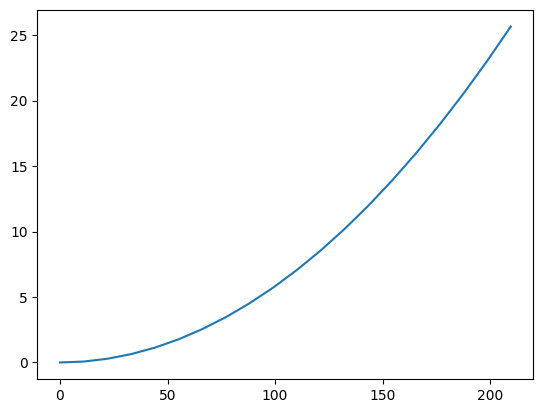

In [78]:
plt.plot(x0, z0)
plt.show()

In [79]:
q0=np.zeros(12*N)

In [80]:
for j in range(1,12):
    if j==1:
        q0[(j-1)*N:j*N]=x0
    elif j==5:
        q0[(j-1)*N:j*N]=z0

In [81]:
def static_func(Q): 
    t=0

    x,y,z=Q[0:N],Q[2*N:3*N],Q[4*N:5*N]
    dx,dy,dz=Q[1*N:2*N],Q[3*N:4*N],Q[5*N:6*N]
    φ,θ,ψ=Q[6*N:7*N],Q[8*N:9*N],Q[10*N:11*N]
    dφ,dθ,dψ=Q[7*N:8*N],Q[9*N:10*N],Q[11*N:12*N]
    
    dx = dy = dz = np.zeros(N)
    dφ = dθ = dψ = np.zeros(N)
    
    RET = Ret(φ,θ,ψ)

    η = [x[-1],y[-1],z[-1],φ[-1],θ[-1],ψ[-1]]

    tau_force = np.array([-Fx_0,Fy_0,0,0,0,0])

    Z0 = tau_force[:3]    
    Z1 = d_s(ne, x, y, z, φ, θ, ψ, dφ, dθ, dψ).T
    Z2 = ne_hat(x, y, z, dx, dy, dz).T


    Z = (Z1 + Z2 - Z0)


############################################################
    ddx,ddy, ddz = (Z/mp).T
############################################################
    
    C0 = np.einsum('ijk,kp->ijp', Π(φ,θ,ψ), tau_force[3:].reshape(3,1))
    C1 = d_s(me, dφ, dθ, dψ, φ, θ, ψ, dφ, dθ, dψ)
    C = (C1.T - C0.squeeze())
 
    A0 = Jrho(RET,Jrho0)
    A_fin = np.einsum('ijk,ikr->ijr',A0, Π(φ,θ,ψ))

    B = np.einsum('ijk,ik->ij', dΠ(φ, θ, ψ, dφ, dθ, dψ), np.stack((dφ,dθ,dψ), axis=1))
    
    D = w_e(φ,θ,ψ,dφ,dθ,dψ)
    
    G = np.cross(d_s(phi,x,y,z,φ, θ, ψ, dφ, dθ, dψ).T, ne(x, y, z, φ, θ, ψ, dφ, dθ, dψ))
    L = np.einsum('ijk,ik->ij',RET, (DR@D.T).T) 
    
    H = np.cross(D,np.einsum('ijk,ik->ij', A0, D))

#############################################
    ddφ,ddθ,ddψ = np.linalg.solve(A_fin, C + G - L - H - np.einsum('ijk,ik->ij',A0, B)).T
#############################################

    ans=np.concatenate([dx, ddx, dy, ddy, dz, ddz, dφ, ddφ, dθ, ddθ, dψ, ddψ], axis=0)

    return ans

In [82]:
root_ = root(static_func, q0, method='df-sane')

/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/scipy/optimize/_spectral.py:145: RuntimeWarning: divide by zero encountered in scalar divide
  sigma_k = np.vdot(s_k, s_k) / np.vdot(s_k, y_k)


In [83]:
root_

 message: too many function evaluations required
 success: False
     fun: [ 0.000e+00  0.000e+00 ...  0.000e+00  0.000e+00]
       x: [ 0.000e+00  1.103e+01 ...  0.000e+00  0.000e+00]
     nit: 319
    nfev: 1000
  method: df-sane

In [84]:
x0_, z0_=root_.x[:N],root_.x[4*N:5*N]

In [85]:
# q0 = root_.x                                            # start from static solution

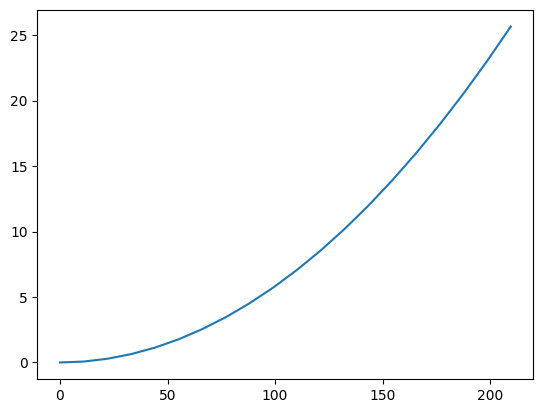

In [86]:
plt.plot(x0_, z0_)
plt.show()

### Finite Element Model of the Space Frame Element

In [87]:
def PlaneTrussElementLength(x1,y1,z1,x2,y2,z2):
    return np.sqrt((x2-x1)*(x2-x1) + (y2-y1)*(y2-y1)+(z2-z1)*(z2-z1))

In [88]:
def SpaceFrameElementStiffness(E,G,A,Iy,Iz,J,x1,y1,z1,x2,y2,z2):
    L = PlaneTrussElementLength(x1,y1,z1,x2,y2,z2)
    w1 = E*A/L
    w2 = 12*E*Iz/(L*L*L)
    w3 = 6*E*Iz/(L*L)
    w4 = 4*E*Iz/L
    w5 = 2*E*Iz/L
    w6 = 12*E*Iy/(L*L*L)
    w7 = 6*E*Iy/(L*L)
    w8 = 4*E*Iy/L
    w9 = 2*E*Iy/L
    w10 = G*J/L

    kprime = np.array([[w1, 0, 0, 0, 0, 0, -w1, 0, 0, 0, 0, 0],
                        [0, w2, 0, 0, 0, w3, 0, -w2, 0, 0, 0, w3],
                        [0, 0, w6, 0, -w7, 0, 0, 0, -w6, 0, -w7, 0],
                        [0, 0, 0, w10, 0, 0, 0, 0, 0, -w10, 0, 0],
                        [0, 0, -w7, 0, w8, 0, 0, 0, w7, 0, w9, 0],
                        [0, w3, 0, 0, 0, w4, 0, -w3, 0, 0, 0, w5],
                        [-w1, 0, 0, 0, 0, 0, w1, 0, 0, 0, 0, 0],
                        [0, -w2, 0, 0, 0, -w3, 0, w2, 0, 0, 0, -w3],
                        [0, 0, -w6, 0, w7, 0, 0, 0, w6, 0, w7, 0],
                        [0, 0, 0, -w10, 0, 0, 0, 0, 0, w10, 0, 0],
                        [0, 0, -w7, 0, w9, 0, 0, 0, w7, 0, w8, 0],
                        [0, w3, 0, 0, 0, w5, 0, -w3, 0, 0, 0, w4]])


    if x1 == x2 and y1 == y2:
        if z2 > z1:
            Lambda = np.array([[0, 0, 1], [0, 1, 0], [-1, 0, 0]])
        else:
            Lambda = np.array([[0, 0, -1], [0, 1, 0], [1, 0, 0]])
    else:
        CXx = (x2-x1)/L
        CYx = (y2-y1)/L
        CZx = (z2-z1)/L
        D = np.sqrt(CXx*CXx + CYx*CYx)
        CXy = -CYx/D
        CYy = CXx/D
        CZy = 0
        CXz = -CXx*CZx/D
        CYz = -CYx*CZx/D
        CZz = D
        Lambda = np.array([[CXx, CYx, CZx], [CXy, CYy, CZy], [CXz, CYz, CZz]])


    R = np.array([np.concatenate((np.concatenate((Lambda,np.zeros((3,3)),np.zeros((3,3)),np.zeros((3,3))),axis=1),
        np.concatenate((np.zeros((3,3)), Lambda, np.zeros((3,3)), np.zeros((3,3))),axis=1) ,
        np.concatenate((np.zeros((3,3)), np.zeros((3,3)), Lambda, np.zeros((3,3))),axis=1),
        np.concatenate((np.zeros((3,3)), np.zeros((3,3)), np.zeros((3,3)), Lambda),axis=1)))])[0]
#     return np.dot(np.dot(R.T,kprime),R)
    return np.array(R.T@ kprime @ R)

In [89]:
def SpaceFrameAssemble(K,k,i,j):
    K[6*i,6*i] = K[6*i,6*i] + k[0,0]
    K[6*i,6*i+1] = K[6*i,6*i+1] + k[0,1]
    K[6*i,6*i+2] = K[6*i,6*i+2] + k[0,2]
    K[6*i,6*i+3] = K[6*i,6*i+3] + k[0,3]
    K[6*i,6*i+4] = K[6*i,6*i+4] + k[0,4]
    K[6*i,6*i+5] = K[6*i,6*i+5] + k[0,5]
    K[6*i,6*j] = K[6*i,6*j] + k[0,6]
    K[6*i,6*j+1] = K[6*i,6*j+1] + k[0,7]
    K[6*i,6*j+2] = K[6*i,6*j+2] + k[0,8]
    K[6*i,6*j+3] = K[6*i,6*j+3] + k[0,9]
    K[6*i,6*j+4] = K[6*i,6*j+4] + k[0,10]
    K[6*i,6*j+5] = K[6*i,6*j+5] + k[0,11]
    K[6*i+1,6*i] = K[6*i+1,6*i] + k[1,0]
    K[6*i+1,6*i+1] = K[6*i+1,6*i+1] + k[1,1]
    K[6*i+1,6*i+2] = K[6*i+1,6*i+2] + k[1,2]
    K[6*i+1,6*i+3] = K[6*i+1,6*i+3] + k[1,3]
    K[6*i+1,6*i+4] = K[6*i+1,6*i+4] + k[1,4]
    K[6*i+1,6*i+5] = K[6*i+1,6*i+5] + k[1,5]
    K[6*i+1,6*j] = K[6*i+1,6*j] + k[1,6]
    K[6*i+1,6*j+1] = K[6*i+1,6*j+1] + k[1,7]
    K[6*i+1,6*j+2] = K[6*i+1,6*j+2] + k[1,8]
    K[6*i+1,6*j+3] = K[6*i+1,6*j+3] + k[1,9]
    K[6*i+1,6*j+4] = K[6*i+1,6*j+4] + k[1,10]
    K[6*i+1,6*j+5] = K[6*i+1,6*j+5] + k[1,11]
    K[6*i+2,6*i]   = K[6*i+2,6*i] + k[2,0]
    K[6*i+2,6*i+1] = K[6*i+2,6*i+1] + k[2,1]
    K[6*i+2,6*i+2] = K[6*i+2,6*i+2] + k[2,2]
    K[6*i+2,6*i+3] = K[6*i+2,6*i+3] + k[2,3]
    K[6*i+2,6*i+4] = K[6*i+2,6*i+4] + k[2,4]
    K[6*i+2,6*i+5] = K[6*i+2,6*i+5] + k[2,5]
    K[6*i+2,6*j]   = K[6*i+2,6*j] + k[2,6]
    K[6*i+2,6*j+1] = K[6*i+2,6*j+1] + k[2,7]
    K[6*i+2,6*j+2] = K[6*i+2,6*j+2] + k[2,8]
    K[6*i+2,6*j+3] = K[6*i+2,6*j+3] + k[2,9]
    K[6*i+2,6*j+4] = K[6*i+2,6*j+4] + k[2,10]
    K[6*i+2,6*j+5] = K[6*i+2,6*j+5] + k[2,11]
    K[6*i+3,6*i] = K[6*i+3,6*i] + k[3,0]
    K[6*i+3,6*i+1] = K[6*i+3,6*i+1] + k[3,1]
    K[6*i+3,6*i+2] = K[6*i+3,6*i+2] + k[3,2]
    K[6*i+3,6*i+3] = K[6*i+3,6*i+3] + k[3,3]
    K[6*i+3,6*i+4] = K[6*i+3,6*i+4] + k[3,4]
    K[6*i+3,6*i+5] = K[6*i+3,6*i+5] + k[3,5]
    K[6*i+3,6*j] = K[6*i+3,6*j] + k[3,6]
    K[6*i+3,6*j+1] = K[6*i+3,6*j+1] + k[3,7]
    K[6*i+3,6*j+2] = K[6*i+3,6*j+2] + k[3,8]
    K[6*i+3,6*j+3] = K[6*i+3,6*j+3] + k[3,9]
    K[6*i+3,6*j+4] = K[6*i+3,6*j+4] + k[3,10]
    K[6*i+3,6*j+5] = K[6*i+3,6*j+5] + k[3,11]
    K[6*i+4,6*i] = K[6*i+4,6*i] + k[4,0]
    K[6*i+4,6*i+1] = K[6*i+4,6*i+1] + k[4,1]
    K[6*i+4,6*i+2] = K[6*i+4,6*i+2] + k[4,2]
    K[6*i+4,6*i+3] = K[6*i+4,6*i+3] + k[4,3]
    K[6*i+4,6*i+4] = K[6*i+4,6*i+4] + k[4,4]
    K[6*i+4,6*i+5] = K[6*i+4,6*i+5] + k[4,5]
    K[6*i+4,6*j] = K[6*i+4,6*j] + k[4,6]
    K[6*i+4,6*j+1] = K[6*i+4,6*j+1] + k[4,7]
    K[6*i+4,6*j+2] = K[6*i+4,6*j+2] + k[4,8]
    K[6*i+4,6*j+3] = K[6*i+4,6*j+3] + k[4,9]
    K[6*i+4,6*j+4] = K[6*i+4,6*j+4] + k[4,10]
    K[6*i+4,6*j+5] = K[6*i+4,6*j+5] + k[4,11]
    K[6*i+5,6*i] = K[6*i+5,6*i] + k[5,0]
    K[6*i+5,6*i+1] = K[6*i+5,6*i+1] + k[5,1]
    K[6*i+5,6*i+2] = K[6*i+5,6*i+2] + k[5,2]
    K[6*i+5,6*i+3] = K[6*i+5,6*i+3] + k[5,3]
    K[6*i+5,6*i+4] = K[6*i+5,6*i+4] + k[5,4]
    K[6*i+5,6*i+5] = K[6*i+5,6*i+5] + k[5,5]
    K[6*i+5,6*j] = K[6*i+5,6*j] + k[5,6]
    K[6*i+5,6*j+1] = K[6*i+5,6*j+1] + k[5,7]
    K[6*i+5,6*j+2] = K[6*i+5,6*j+2] + k[5,8]
    K[6*i+5,6*j+3] = K[6*i+5,6*j+3] + k[5,9]
    K[6*i+5,6*j+4] = K[6*i+5,6*j+4] + k[5,10]
    K[6*i+5,6*j+5] = K[6*i+5,6*j+5] + k[5,11]
    K[6*j,6*i] = K[6*j,6*i] + k[6,0]
    K[6*j,6*i+1] = K[6*j,6*i+1] + k[6,1]
    K[6*j,6*i+2] = K[6*j,6*i+2] + k[6,2]
    K[6*j,6*i+3] = K[6*j,6*i+3] + k[6,3]
    K[6*j,6*i+4] = K[6*j,6*i+4] + k[6,4]
    K[6*j,6*i+5] = K[6*j,6*i+5] + k[6,5]
    K[6*j,6*j] = K[6*j,6*j] + k[6,6]
    K[6*j,6*j+1] = K[6*j,6*j+1] + k[6,7]
    K[6*j,6*j+2] = K[6*j,6*j+2] + k[6,8]
    K[6*j,6*j+3] = K[6*j,6*j+3] + k[6,9]
    K[6*j,6*j+4] = K[6*j,6*j+4] + k[6,10]
    K[6*j,6*j+5] = K[6*j,6*j+5] + k[6,11]
    K[6*j+1,6*i] = K[6*j+1,6*i] + k[7,0]
    K[6*j+1,6*i+1] = K[6*j+1,6*i+1] + k[7,1]
    K[6*j+1,6*i+2] = K[6*j+1,6*i+2] + k[7,2]
    K[6*j+1,6*i+3] = K[6*j+1,6*i+3] + k[7,3]
    K[6*j+1,6*i+4] = K[6*j+1,6*i+4] + k[7,4]
    K[6*j+1,6*i+5] = K[6*j+1,6*i+5] + k[7,5]
    K[6*j+1,6*j] = K[6*j+1,6*j] + k[7,6]
    K[6*j+1,6*j+1] = K[6*j+1,6*j+1] + k[7,7]
    K[6*j+1,6*j+2] = K[6*j+1,6*j+2] + k[7,8]
    K[6*j+1,6*j+3] = K[6*j+1,6*j+3] + k[7,9]
    K[6*j+1,6*j+4] = K[6*j+1,6*j+4] + k[7,10]
    K[6*j+1,6*j+5] = K[6*j+1,6*j+5] + k[7,11]
    K[6*j+2,6*i] = K[6*j+2,6*i] + k[8,0]
    K[6*j+2,6*i+1] = K[6*j+2,6*i+1] + k[8,1]
    K[6*j+2,6*i+2] = K[6*j+2,6*i+2] + k[8,2]
    K[6*j+2,6*i+3] = K[6*j+2,6*i+3] + k[8,3]
    K[6*j+2,6*i+4] = K[6*j+2,6*i+4] + k[8,4]
    K[6*j+2,6*i+5] = K[6*j+2,6*i+5] + k[8,5]
    K[6*j+2,6*j] = K[6*j+2,6*j] + k[8,6]
    K[6*j+2,6*j+1] = K[6*j+2,6*j+1] + k[8,7]
    K[6*j+2,6*j+2] = K[6*j+2,6*j+2] + k[8,8]
    K[6*j+2,6*j+3] = K[6*j+2,6*j+3] + k[8,9]
    K[6*j+2,6*j+4] = K[6*j+2,6*j+4] + k[8,10]
    K[6*j+2,6*j+5] = K[6*j+2,6*j+5] + k[8,11]
    K[6*j+3,6*i] = K[6*j+3,6*i] + k[9,0]
    K[6*j+3,6*i+1] = K[6*j+3,6*i+1] + k[9,1]
    K[6*j+3,6*i+2] = K[6*j+3,6*i+2] + k[9,2]
    K[6*j+3,6*i+3] = K[6*j+3,6*i+3] + k[9,3]
    K[6*j+3,6*i+4] = K[6*j+3,6*i+4] + k[9,4]
    K[6*j+3,6*i+5] = K[6*j+3,6*i+5] + k[9,5]
    K[6*j+3,6*j] = K[6*j+3,6*j] + k[9,6]
    K[6*j+3,6*j+1] = K[6*j+3,6*j+1] + k[9,7]
    K[6*j+3,6*j+2] = K[6*j+3,6*j+2] + k[9,8]
    K[6*j+3,6*j+3] = K[6*j+3,6*j+3] + k[9,9]
    K[6*j+3,6*j+4] = K[6*j+3,6*j+4] + k[9,10]
    K[6*j+3,6*j+5] = K[6*j+3,6*j+5] + k[9,11]
    K[6*j+4,6*i] = K[6*j+4,6*i] + k[10,0]
    K[6*j+4,6*i+1] = K[6*j+4,6*i+1] + k[10,1]
    K[6*j+4,6*i+2] = K[6*j+4,6*i+2] + k[10,2]
    K[6*j+4,6*i+3] = K[6*j+4,6*i+3] + k[10,3]
    K[6*j+4,6*i+4] = K[6*j+4,6*i+4] + k[10,4]
    K[6*j+4,6*i+5] = K[6*j+4,6*i+5] + k[10,5]
    K[6*j+4,6*j] = K[6*j+4,6*j] + k[10,6]
    K[6*j+4,6*j+1] = K[6*j+4,6*j+1] + k[10,7]
    K[6*j+4,6*j+2] = K[6*j+4,6*j+2] + k[10,8]
    K[6*j+4,6*j+3] = K[6*j+4,6*j+3] + k[10,9]
    K[6*j+4,6*j+4] = K[6*j+4,6*j+4] + k[10,10]
    K[6*j+4,6*j+5] = K[6*j+4,6*j+5] + k[10,11]
    K[6*j+5,6*i] = K[6*j+5,6*i] + k[11,0]
    K[6*j+5,6*i+1] = K[6*j+5,6*i+1] + k[11,1]
    K[6*j+5,6*i+2] = K[6*j+5,6*i+2] + k[11,2]
    K[6*j+5,6*i+3] = K[6*j+5,6*i+3] + k[11,3]
    K[6*j+5,6*i+4] = K[6*j+5,6*i+4] + k[11,4]
    K[6*j+5,6*i+5] = K[6*j+5,6*i+5] + k[11,5]
    K[6*j+5,6*j] = K[6*j+5,6*j] + k[11,6]
    K[6*j+5,6*j+1] = K[6*j+5,6*j+1] + k[11,7]
    K[6*j+5,6*j+2] = K[6*j+5,6*j+2] + k[11,8]
    K[6*j+5,6*j+3] = K[6*j+5,6*j+3] + k[11,9]
    K[6*j+5,6*j+4] = K[6*j+5,6*j+4] + k[11,10]
    K[6*j+5,6*j+5] = K[6*j+5,6*j+5] + k[11,11]

    return K

In [90]:
def FEA(coord, elcon, bc_node, bc_val, vessel_movement, coefs,
          E=210e6, G=84e6, A=2e-2, Iy=10e-5, Iz=20e-5, J=5e-5):

    coord=np.array(coord)
    elcon=np.array(elcon)

    K=np.zeros(shape=(6*(np.max(elcon)+1),6*(np.max(elcon)+1)))

    for el in elcon:
        k=SpaceFrameElementStiffness(E,G,A,Iy,Iz,J,
                                     coord[el[0]][0],coord[el[0]][1],coord[el[0]][2],\
                                     coord[el[1]][0],coord[el[1]][1],coord[el[1]][2])
        K=SpaceFrameAssemble(K,k,el[0],el[1])
        
        
    glob_force=np.dot(K, np.array(vessel_movement))
    
    glob_force[-6:]=np.multiply(glob_force[-6:], coefs)
    glob_force = np.zeros(len(vessel_movement))


    F=np.zeros(len(coord)*6)
    for i in range(len(vessel_movement)):
        if vessel_movement[i]:
            F[i]=glob_force[i]

    # https://github.com/CALFEM/calfem-matlab/blob/master/fem/solveq.m

    bc=np.array([bc_node,
                bc_val]).T
    nd, nd=K.shape
    fdof=np.array([i for i in range(nd)]).T
    d=np.zeros(shape=(len(fdof),))
    Q=np.zeros(shape=(len(fdof),))

    pdof=bc[:,0].astype(int)
    dp=bc[:,1]
    fdof=np.delete(fdof, pdof, 0)
    s=scipy.linalg.lstsq(K[fdof,:][:,fdof], (F[fdof].T-np.dot(K[fdof,:][:,pdof],dp.T)).T, check_finite=True)[0]
    d[pdof]=dp
    d[fdof]=s.reshape(-1,)
    

#     Q=np.dot(K,d).T-F
    return d, np.dot(K,d).T

In [91]:
# 10 The Space Frame Element - verification
d,f=FEA(np.array([0,0,0,
                  3,0,0,
                  0,0,-3,
                  0,-4,0]).reshape(4,3),
        elcon=np.array([[0, 1],
                      [0, 2],
                      [0, 3]]),
        bc_node=list(range(6)),
        bc_val=[ -0.0705e-4, -0.0007e-4, 0.1418e-4, 0.0145e-4, 0.0175e-4,0.0114e-4],
        vessel_movement=[ 0, 0, 0, 0, 0,0.0,
                                0,0,0,0,0,0,
                                0,0,0,0,0,0,
                                0,0,0,0,0,0,
                       ],
        coefs=[1,1,1,1,1,1])

In [92]:
d

array([-7.050e-06, -7.000e-08,  1.418e-05,  1.450e-06,  1.750e-06,
        1.140e-06, -7.050e-06,  3.350e-06,  8.930e-06,  1.450e-06,
        1.750e-06,  1.140e-06, -1.230e-05,  4.280e-06,  1.418e-05,
        1.450e-06,  1.750e-06,  1.140e-06, -2.490e-06, -7.000e-08,
        8.380e-06,  1.450e-06,  1.750e-06,  1.140e-06])

In [93]:
f

array([ 2.18575158e-15, -1.86923231e-17, -3.84067778e-15,  9.71445147e-17,
        4.94078553e-17, -1.38777878e-17, -5.59719372e-16, -2.94360890e-17,
        2.29749217e-17,  3.06625927e-19,  2.51331616e-17,  5.88721780e-17,
        1.93123512e-17,  1.42708111e-17,  1.72398987e-15, -2.85416222e-17,
        6.63802780e-17, -6.09863722e-20,  2.08166817e-17,  4.64478987e-17,
        2.42861287e-17,  1.38777878e-17,  3.17637355e-20, -1.38777878e-17])

In [94]:
def PipeForce(X,Y,Z,vessel_movement,coefs, E=E, G=G, A=Ar, Iy=Iy_, Iz=Iz_, J=J_):
    coord=np.stack((X,Y,Z)).T
    elcon=[]
    for i in range(1,len(X)):
        elcon.append([i-1,i])
    
#     bc_node = list(range(3))+list(range((6*len(X)-6),6*len(X)))
#     bc_val = [0]*3 + vessel_movement
    
    bc_node = list(range(6)) + list(range((6*len(X)-6), 6*len(X)))
    bc_val  = [0]*6 + vessel_movement
    
    vessel_move=np.zeros(len(X)*6)

    d, f = FEA(coord,elcon,bc_node,bc_val,vessel_move, coefs, E,G,A,Iy,Iz,J)

    fors=[]
    for i in range(0,len(f),6):
        fors.append(f[i:i+3])

    mom =[]
    for i in range(3,len(f),6):
        mom.append(f[i:i+3])

    angle=[]
    for i in range(3,len(d),6):
        angle.append(d[i:i+3])
    fors[0][0]=0
    fors[0][1]=0
    fors[0][2]=0
    return np.array(fors), np.array(mom), np.array(angle)

In [95]:
fors, mom, angle = PipeForce(x0_,list([0 for i in range(len(z0))]),z0_,
[0.01,
 0.02,
 0.03,
 0.01,
 -0.05,
 0.03],
 [1,1,1,1,1,1]
)

In [96]:
fors

array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 1.24153495e-03, -4.27913666e-03, -6.16455078e-03],
       [ 5.59306145e-03,  4.91142273e-04, -1.57928467e-03],
       [ 3.37499380e-03,  1.25312805e-03,  5.43594360e-03],
       [-6.32679462e-03,  5.64575195e-04,  7.97271729e-04],
       [ 4.36115265e-03,  3.87573242e-03,  9.15527344e-05],
       [-8.58306885e-04, -6.10351562e-05, -5.61523438e-03],
       [-8.69750977e-04,  3.47137451e-04, -1.19018555e-03],
       [ 3.32355499e-04,  2.13623047e-03,  4.07409668e-03],
       [ 9.80377197e-04, -2.56347656e-03,  2.47192383e-03],
       [ 1.12915039e-03,  3.41796875e-03, -5.18798828e-03],
       [ 9.30786133e-04, -2.59399414e-04, -5.85937500e-03],
       [-5.82218170e-04, -6.10351562e-04,  4.11796570e-03],
       [-1.44958496e-03,  3.29589844e-03,  4.60815430e-03],
       [-1.15966797e-03, -3.90625000e-03,  1.03759766e-03],
       [-5.46928652e-04,  1.30848997e-03, -4.01521354e-03],
       [-3.30252746e-04,  2.42830133e-03

In [97]:
mom

array([[-2.89797571e+06, -1.01973460e+10,  8.26188164e+07],
       [-9.65595245e-06, -1.12915039e-03, -1.15966797e-03],
       [ 3.89575958e-04,  9.53674316e-04,  9.38415527e-03],
       [-1.90067291e-03,  2.01416016e-03, -9.34600830e-03],
       [ 4.57763672e-05,  7.70568848e-04,  1.22070312e-04],
       [ 1.43051147e-04, -2.44140625e-04, -1.12915039e-03],
       [ 1.40380859e-03, -2.44140625e-04,  5.37109375e-03],
       [-9.65118408e-04, -1.22070312e-03,  7.14111328e-03],
       [ 1.83105469e-04,  1.28936768e-03, -9.76562500e-03],
       [ 5.59329987e-04,  1.70898438e-03, -4.82177734e-03],
       [ 1.83105469e-04, -2.05993652e-04,  5.12695312e-03],
       [ 8.54492188e-04, -1.95312500e-03, -1.22070312e-02],
       [-2.44140625e-04, -2.42996216e-03,  4.39453125e-03],
       [ 3.50952148e-04,  1.22070312e-03, -1.22070312e-03],
       [-7.62939453e-05, -1.51824951e-03,  8.54492188e-04],
       [ 1.73845215e-03,  1.00247797e-03, -1.20674850e-02],
       [-1.05440897e-03, -8.14021992e-04

In [98]:
angle

array([[ 0.        ,  0.        ,  0.        ],
       [ 0.11797009,  0.00466639,  0.00073753],
       [ 0.18906908,  0.00855444,  0.00208903],
       [ 0.21925491,  0.01166004,  0.00304277],
       [ 0.21449707,  0.01397869,  0.0028166 ],
       [ 0.18077354,  0.01550549,  0.00085818],
       [ 0.12406792,  0.01623514, -0.00315478],
       [ 0.05036637,  0.01616193, -0.00931435],
       [-0.03434527,  0.01527975, -0.01748228],
       [-0.1240845 ,  0.01358204, -0.02728998],
       [-0.21287505,  0.01106184, -0.03813856],
       [-0.29474981,  0.00771176, -0.04919887],
       [-0.36375372,  0.00352395, -0.05941171],
       [-0.41394662, -0.00150986, -0.06748798],
       [-0.43940605, -0.00739841, -0.07190898],
       [-0.43423003, -0.01415087, -0.07092669],
       [-0.39253981, -0.02177691, -0.06256415],
       [-0.30848249, -0.03028663, -0.04461585],
       [-0.17623367, -0.03969063, -0.0146482 ],
       [ 0.01      , -0.05      ,  0.03      ]])

### Vessle Simulation

In [99]:
sampleTime = 0.01              # sample time [seconds]
Number = 60000                      # number of samples

In [100]:
Number*sampleTime

600.0

In [101]:
vehicle=semisub('DPcontrol',1,-1,0.0,0,0)

In [102]:
[simTime, simData] = simulate(Number, sampleTime, vehicle)

In [103]:
ans_t=[]
sum_=0
for i in range(simData.shape[0]):
    ans_t.append(sum_)
    sum_+=sampleTime

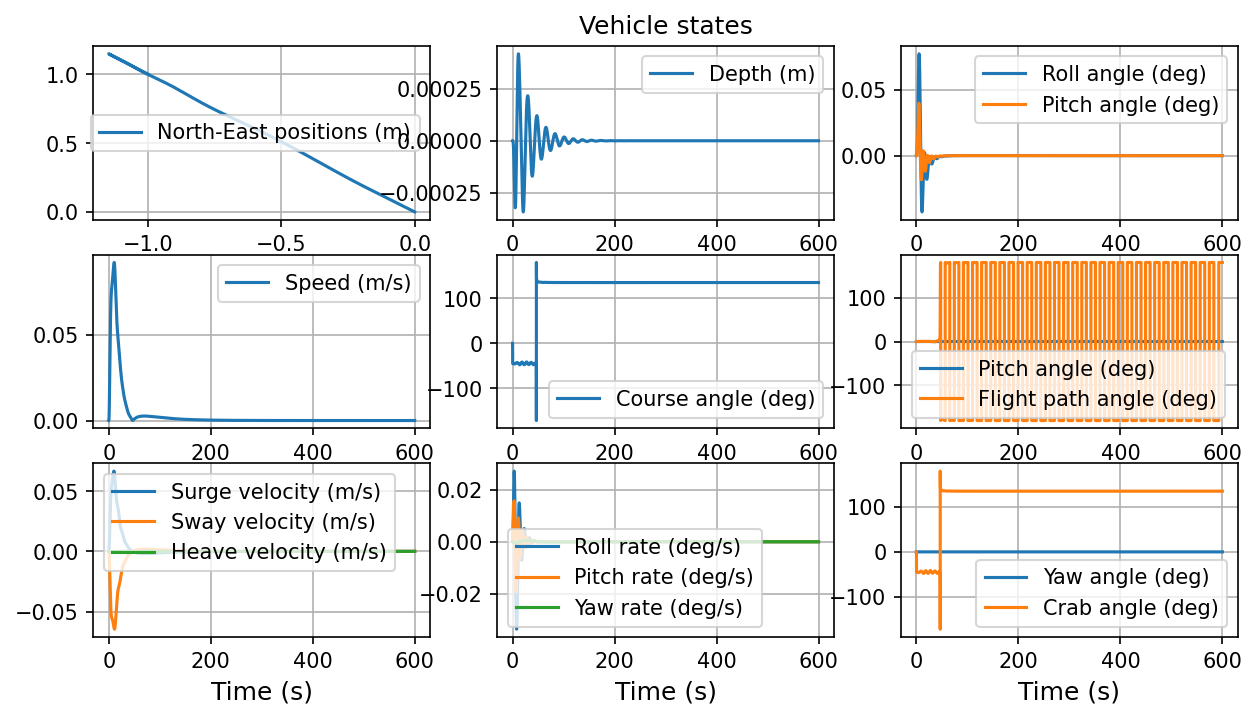

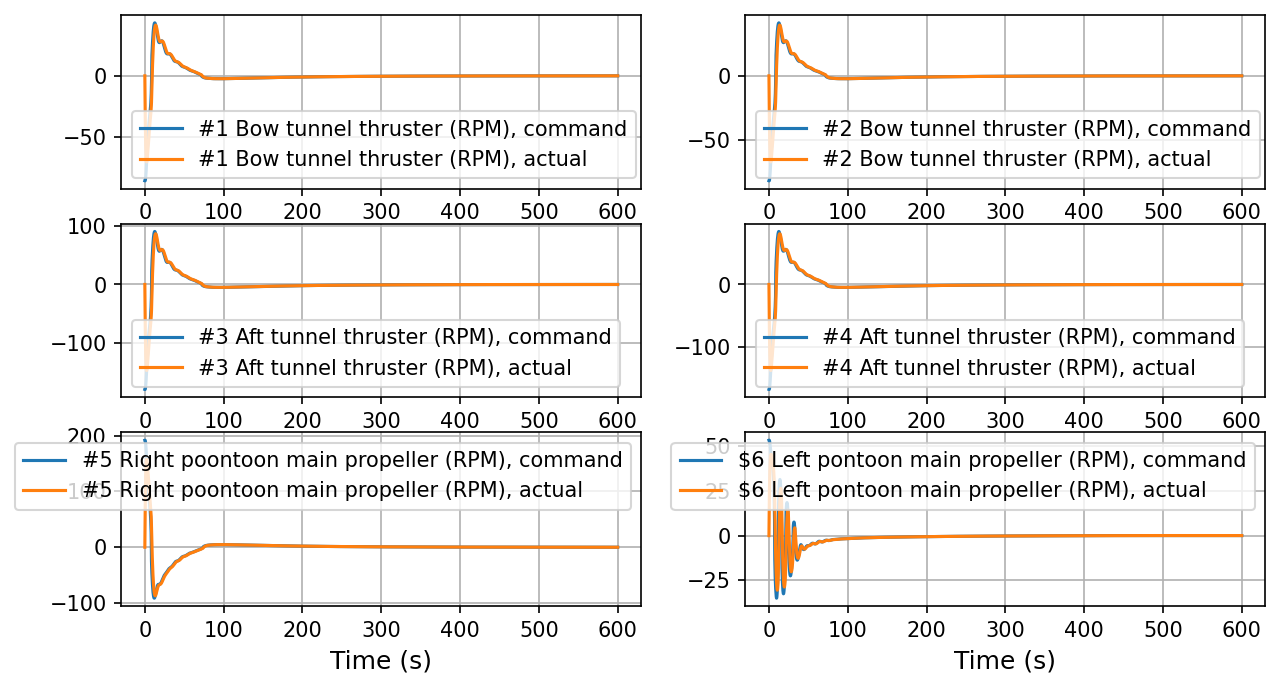

In [104]:
plotVehicleStates(simTime, simData, 1)
plotControls(simTime, simData, vehicle, 2)

In [105]:
numDataPoints = 5                 # number of 3D data points
FPS = 10                            # frames per second (animated GIF)
filename = '3D_animation.gif'       # data file for animated GIF
browser = 'safari'

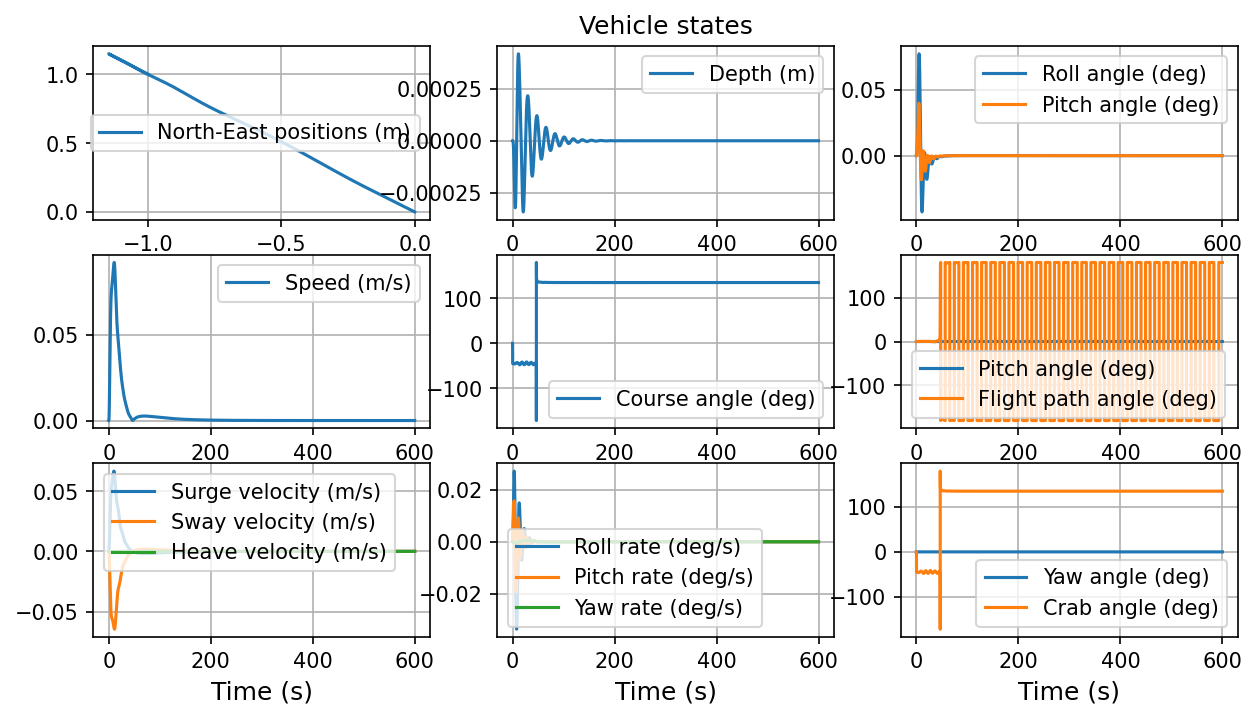

In [106]:
plotVehicleStates(simTime, simData, 3)

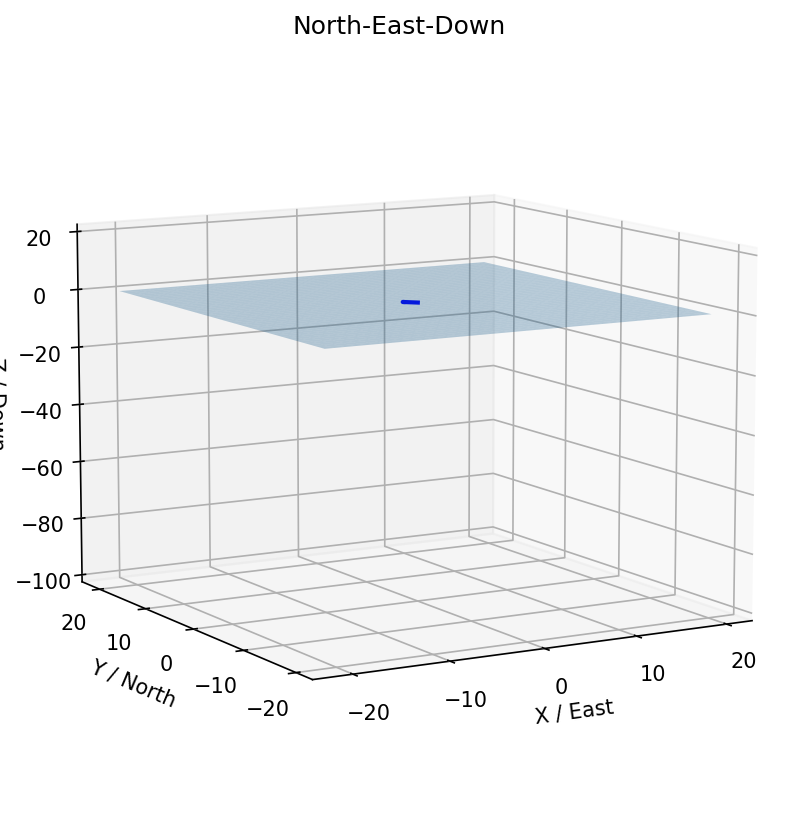

In [107]:
plot3D(simData, numDataPoints, FPS, filename, 3)

In [108]:
def find_nearest(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return idx

In [109]:
class MyTime:
    def __init__(self):
        self.my_t = 0
        self.v_m = np.array([0,0,0,0,0,0]).astype(np.float64)
        self.progression = [i for i in range(650)]
        self.wall_clock = datetime.now()
        self.x_ve = 0
        self.y_ve = 0
        self.z_ve = 0
        self.phi_ve = 0
        self.theta_ve = 0
        self.psi_ve = 0
        self.top_tension = 0
        self.sagbend_strain = 0
        self.my_iter = 0

In [110]:
def inert(M, m, X):
    sum_=M
    ans=[]
    for i in range(len(X)-1,-1,-1):
        sum_+=m
        ans.append(np.array(sum_).copy())
    return np.array(ans)  

In [111]:
# V_rho=np.zeros(Jrho0.shape)
# np.fill_diagonal(V_rho, vessel_inertia)

In [112]:
# M_t=inert(vessel_mass*9.81,mp*9.81, x0)
# Jrho1=inert(V_rho, Jrho0, x0)

### Dynamics

In [113]:
def dynamic_func(t, Q, coefs, T, calibr):
    
    x,y,z=Q[0:N],Q[2*N:3*N],Q[4*N:5*N]
    dx,dy,dz=Q[1*N:2*N],Q[3*N:4*N],Q[5*N:6*N]
    φ,θ,ψ=Q[6*N:7*N],Q[8*N:9*N],Q[10*N:11*N]
    dφ,dθ,dψ=Q[7*N:8*N],Q[9*N:10*N],Q[11*N:12*N]
    
    idx = find_nearest(np.array(ans_t),  t)
    
    del_t = idx-T.my_t
    if del_t<0:
        idx=T.my_t
        
    x_ve = simData[:, 0][idx]
    y_ve = simData[:, 1][idx]
    z_ve = simData[:, 2][idx]
    phi_ve = ssa(simData[:, 3][idx])
    theta_ve = ssa(simData[:, 4][idx])
    psi_ve = ssa(simData[:, 5][idx])
    
    RET = Ret(φ,θ,ψ)

    vessel_movement = np.zeros(6)
    
    
    vessel_movement[0] = (x_ve - T.x_ve)
    vessel_movement[1] = (y_ve - T.y_ve)
    vessel_movement[2] = (z_ve - T.z_ve)
    vessel_movement[3] = (phi_ve - T.phi_ve)
    vessel_movement[4] = (theta_ve - T.theta_ve)
    vessel_movement[5] = (psi_ve - T.psi_ve)

    vessel_movement/=calibr
#     print(vessel_movement)    

    fors, mom, angle = PipeForce(x, y, z, list(vessel_movement), coefs)
    
    Z0 = fors.squeeze()
    Z1 = d_s(ne, x, y, z, φ, θ, ψ, dφ, dθ, dψ).T
    Z2 = ne_hat(x, y, z, dx, dy, dz).T

    Z = (Z1 + Z2 - Z0)
#     print(Z0)


############################################################
#     ddx,ddy, ddz = (Z/(M_t.reshape(-1, 1))).T
    ddx,ddy, ddz = (Z/mp).T    
############################################################
    
    C0 = np.einsum('ijk,ik->ij', Π(φ,θ,ψ), angle).squeeze()    
    C1 = d_s(me, dφ, dθ, dψ, φ, θ, ψ, dφ, dθ, dψ)
    C = (C1.T - C0)

    A0 = Jrho(RET,Jrho0)
#     A0 = Jrho(RET,Jrho1) 
    A_fin = np.einsum('ijk,ikr->ijr', A0, Π(φ,θ,ψ))
    

#     B = np.einsum('ijk,ik->ij', Π(dφ,dθ,dψ), np.stack((dφ,dθ,dψ), axis=1))
    B = np.einsum('ijk,ik->ij',dΠ(φ, θ, ψ, dφ, dθ, dψ), np.stack((dφ,dθ,dψ), axis=1))
    
    D = w_e(φ,θ,ψ,dφ,dθ,dψ)
    
    G = np.cross(d_s(phi,x,y,z,φ, θ, ψ, dφ, dθ, dψ).T, ne(x, y, z, φ, θ, ψ, dφ, dθ, dψ))
    
    L = np.einsum('ijk,ik->ij',RET, (DR@D.T).T) 

    H = np.cross(D, np.einsum('ijk,ik->ij', A0, D))
    

#############################################
    ddφ,ddθ,ddψ = np.linalg.solve(A_fin, (C + G - L - H - np.einsum('ijk,ik->ij', A0, B))).T
#############################################

    T.my_t=idx
    T.x_ve=x_ve
    T.y_ve=y_ve
    T.z_ve=z_ve
    T.phi_ve = phi_ve
    T.theta_ve = theta_ve
    T.psi_ve = psi_ve

    if t>T.progression[0]:
        T.progression.pop(0)
        print('Physical time: ', t, ' Iteration wall-clock time: ', datetime.now() - T.wall_clock )
        T.wall_clock = datetime.now()   
         
    
    ans=np.concatenate([dx, ddx, 
                        dy, ddy, 
                        dz, ddz, 
                        dφ, ddφ, 
                        dθ, ddθ, 
                        dψ, ddψ
                       ], axis=0)
   
   
    if t>1:
        ax=np.einsum('ijk,ik->ij',np.linalg.inv(RET),ne(x, y, z, φ, θ, ψ, dφ, dθ, dψ))
        
        T.top_tension=max(T.top_tension, np.max(ax[-1,:]))
    
        ben=np.max(np.einsum('ijk,ik->ij',np.linalg.inv(RET), 
                         me(dφ, dθ, dψ, φ, θ, ψ)))/(mp*9.81*np.sqrt((x[-1]-x0_[-1])**2+
                                                                 (y[-1]-0)**2+(z[-1]-z0_[-1])**2)**2)

        I=3.14*(d0**4-dI**4)/64
        strain=np.max(ben)*d0/(2*E*I)    
        
        T.sagnend_strain=max(T.sagbend_strain, strain)
    T.my_iter+=1
    
    return ans

In [149]:
T_ = MyTime()

# initial conditions - to control dynamics
q0[6*N:7*N], q0[8*N:9*N], q0[10*N:11*N] = (np.array([0.01 for i in range(N)]),
                                          np.array([0.001 for i in range(N)]),
                                          np.array([0.001257*i/N for i in range(N)]))

# q0[6*N:7*N], q0[8*N:9*N], q0[10*N:11*N] = (np.array([0.12 for i in range(N)]),
#                                           np.array([0.1 for i in range(N)]),
#                                           np.array([0.1257*i/N for i in range(N)]))

In [150]:
startTime1 = datetime.now()
us_ = solve_ivp(dynamic_func,
             tspan,
             q0,
             args=(coefs, T_, vessel_motion_calibration_coefficient,))
print(datetime.now() - startTime1)

Physical time:  1.152469341783057e-05  Iteration wall-clock time:  0:00:00.954507
Physical time:  1.0195806343731215  Iteration wall-clock time:  0:00:28.276823
Physical time:  2.0487745238835  Iteration wall-clock time:  0:00:23.881748
Physical time:  3.0057270343445186  Iteration wall-clock time:  0:00:12.390743
Physical time:  4.040560570113596  Iteration wall-clock time:  0:00:06.978043
Physical time:  5.04124995848582  Iteration wall-clock time:  0:00:05.965371
Physical time:  6.7736214263617125  Iteration wall-clock time:  0:00:06.228565
Physical time:  7.081627303101292  Iteration wall-clock time:  0:00:00.334432
Physical time:  10.05440496639865  Iteration wall-clock time:  0:00:06.123874
Physical time:  10.572939409216985  Iteration wall-clock time:  0:00:00.331361
Physical time:  11.221107462739909  Iteration wall-clock time:  0:00:00.338622
Physical time:  11.221107462739909  Iteration wall-clock time:  0:00:00.410307
0:01:44.673031


In [151]:
# max axial tension
T_.top_tension

2.859367276942644e+24

In [152]:
# max bending strain
T_.sagnend_strain*(mp*9.81*np.sqrt((x[-1]-x0_[-1])**2+(y[-1]-0)**2+(z[-1]-z0_[-1])**2)**2)

0.0

### Results

In [153]:
fin=us_

In [154]:
fin

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  1.152e-03 ...  9.433e+00  1.200e+01]
        y: [[ 0.000e+00  0.000e+00 ...  0.000e+00  0.000e+00]
            [ 1.103e+01  1.103e+01 ...  1.103e+01  1.103e+01]
            ...
            [ 0.000e+00  0.000e+00 ...  0.000e+00  0.000e+00]
            [ 0.000e+00  0.000e+00 ...  0.000e+00  0.000e+00]]
      sol: None
 t_events: None
 y_events: None
     nfev: 308
     njev: 0
      nlu: 0

In [155]:
t=fin.t

In [156]:
fin=fin.y.T

In [157]:
t.shape, fin.shape

((36,), (36, 240))

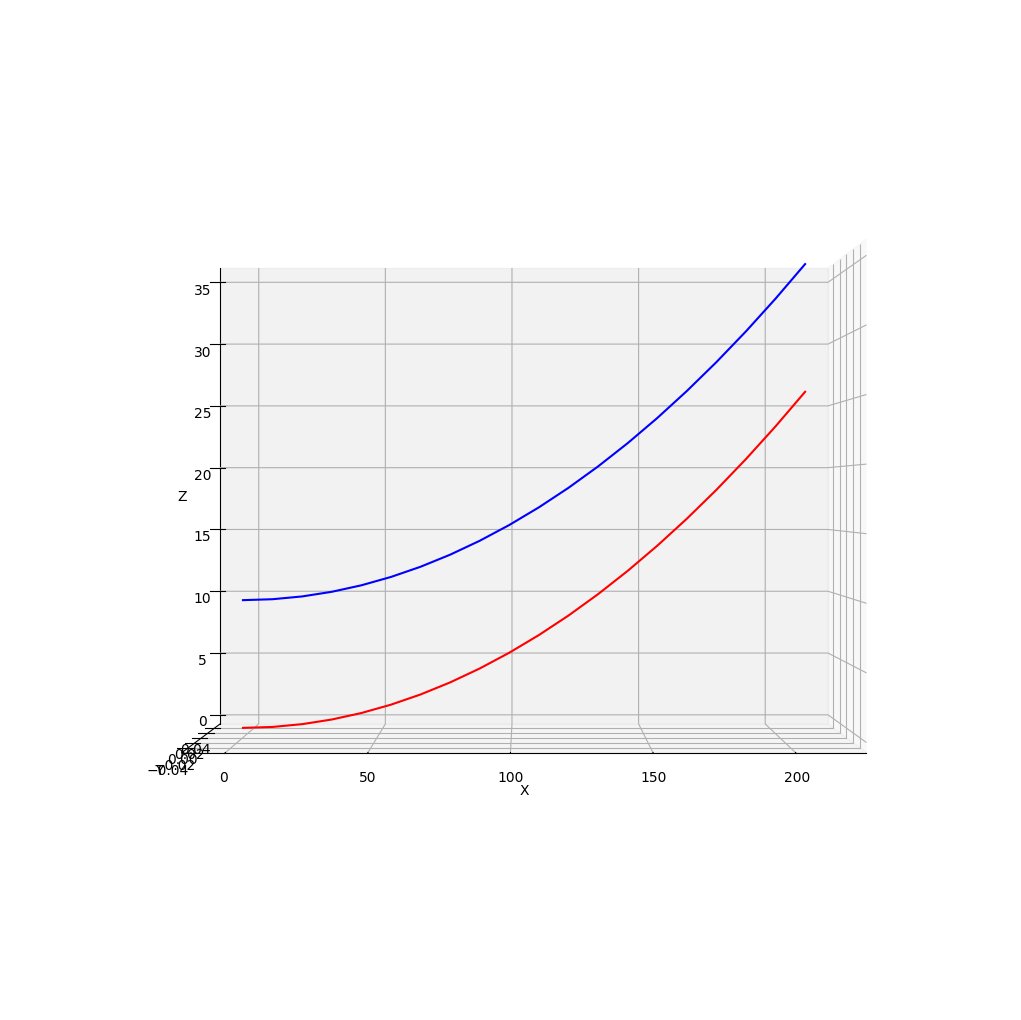

In [158]:
fig=plt.figure(figsize=(13,13))
ax = fig.add_subplot(projection = '3d')

X0=fin[0,[i for i in range(0,N)]]
Y0=fin[0,[i for i in range(2*N,3*N)]]
Z0=fin[0,[i for i in range(4*N,5*N)]]

j=-1
X=fin[j,[i for i in range(0,N)]]
Y=fin[j,[i for i in range(2*N,3*N)]]
Z=fin[j,[i for i in range(4*N,5*N)]]

num_true_pts = 200
tck, u = interpolate.splprep([X,Y,Z], s=2)
u_fine = np.linspace(0,1,num_true_pts)
x_fine, y_fine, z_fine = interpolate.splev(u_fine, tck)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.plot(X0,Y0,Z0, color='r')
ax.plot(X,Y,Z, color='b')
# ax.plot(x_fine, y_fine, z_fine, color='b')
# ax.view_init(-45,-45)
# ax.view_init(-30,-30)
ax.view_init(0,-90)
plt.show()

In [159]:
X,Y,Z

(array([  0.        ,  11.02712714,  22.05425428,  33.08138141,
         44.10850855,  55.13563569,  66.16276283,  77.18988997,
         88.21701711,  99.24414424, 110.27127138, 121.29839852,
        132.32552566, 143.3526528 , 154.37977994, 165.40690707,
        176.43403421, 187.46116135, 198.48828849, 209.51541563]),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0.]),
 array([ 9.75416436,  9.82491089, 10.03716215, 10.39095307, 10.8863419 ,
        11.52341021, 12.30226288, 13.22302814, 14.2858576 , 15.49092623,
        16.83843245, 18.3285981 , 19.96166853, 21.73791261, 23.65762278,
        25.72111512, 27.92872935, 30.28082894, 32.77780115, 35.42005708]))

In [160]:
X0,Y0,Z0

(array([  0.        ,  11.02712714,  22.05425428,  33.08138141,
         44.10850855,  55.13563569,  66.16276283,  77.18988997,
         88.21701711,  99.24414424, 110.27127138, 121.29839852,
        132.32552566, 143.3526528 , 154.37977994, 165.40690707,
        176.43403421, 187.46116135, 198.48828849, 209.51541563]),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0.]),
 array([ 0.        ,  0.07074654,  0.28299779,  0.63678871,  1.13217754,
         1.76924585,  2.54809852,  3.46886379,  4.53169324,  5.73676187,
         7.08426809,  8.57443374, 10.20750417, 11.98374825, 13.90345843,
        15.96695076, 18.17456499, 20.52666459, 23.02363679, 25.66589272]))

In [161]:
us=fin.T

In [162]:
us.shape

(240, 36)

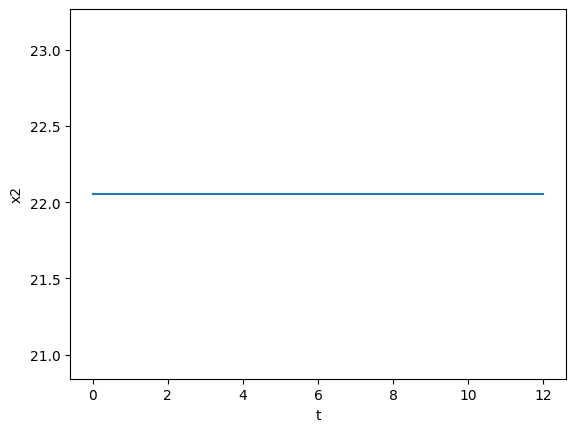

In [163]:
plt.plot(t,us.T[:,2],'-')
plt.xlabel('t')
plt.ylabel('x2')
plt.show()

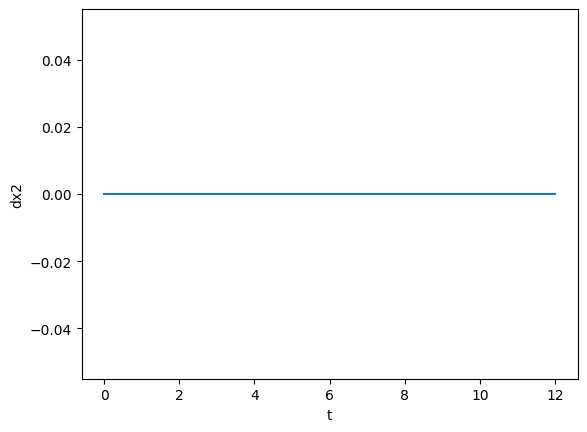

In [164]:
plt.plot(t,us.T[:,N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dx2')
plt.show()

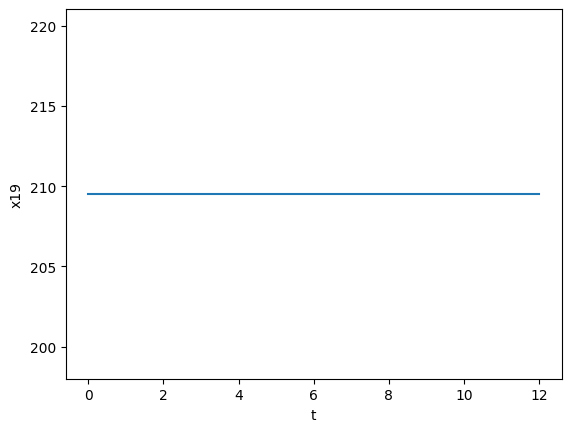

In [165]:
plt.plot(t,us.T[:,N-1] ,'-')
plt.xlabel('t')
plt.ylabel('x{}'.format(N-1))
plt.show()

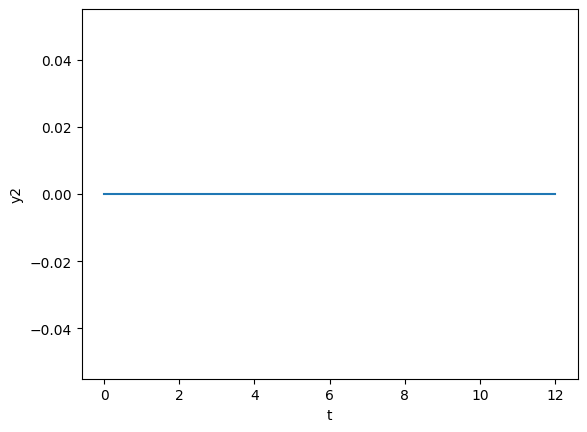

In [166]:
plt.plot(t,us.T[:,2*N +2] ,'-')
plt.xlabel('t')
plt.ylabel('y2')
plt.show()

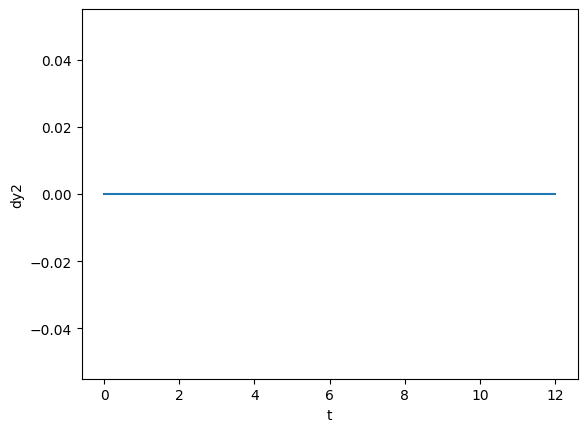

In [167]:
plt.plot(t,us.T[:,3*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dy2')
plt.show()

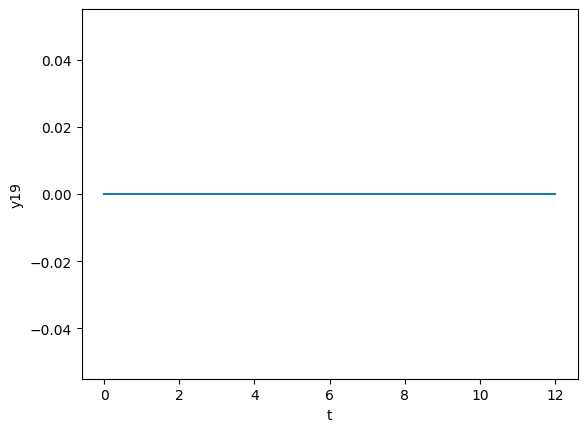

In [168]:
plt.plot(t,us.T[:,2*N+(N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('y{}'.format(N-1))
plt.show()

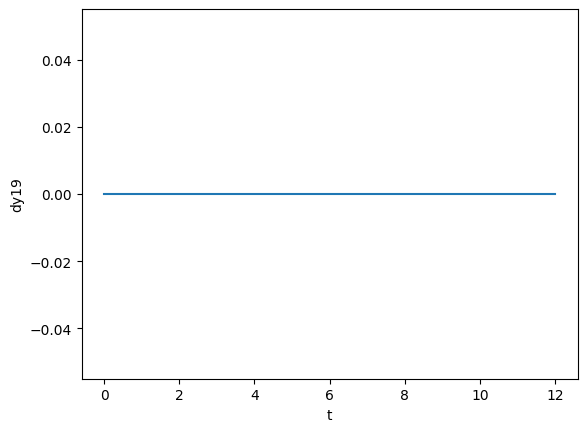

In [169]:
plt.plot(t,us.T[:,3*N+(N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('dy{}'.format(N-1))
plt.show()

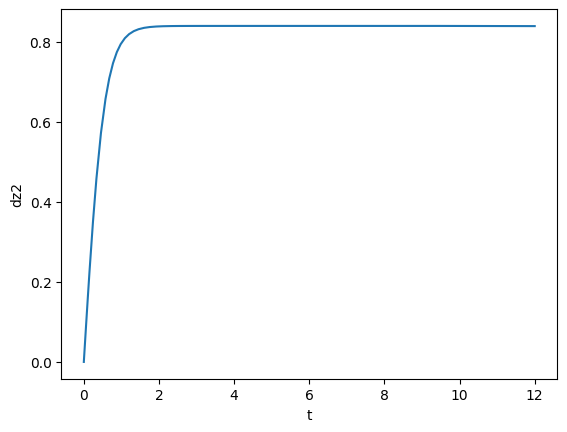

In [170]:
plt.plot(t,us.T[:,5*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dz2')
plt.show()

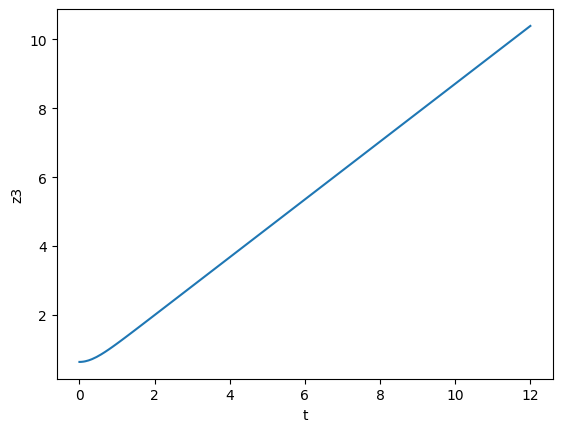

In [171]:
plt.plot(t,us.T[:,4*N+3] ,'-')
plt.xlabel('t')
plt.ylabel('z3')
plt.show()

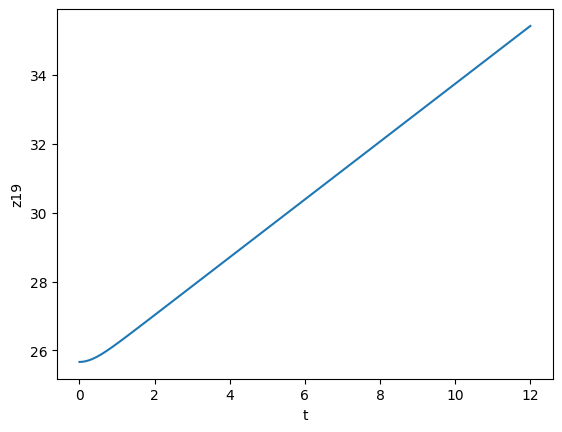

In [172]:
plt.plot(t,us.T[:,4*N + (N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('z{}'.format(N-1))
plt.show()

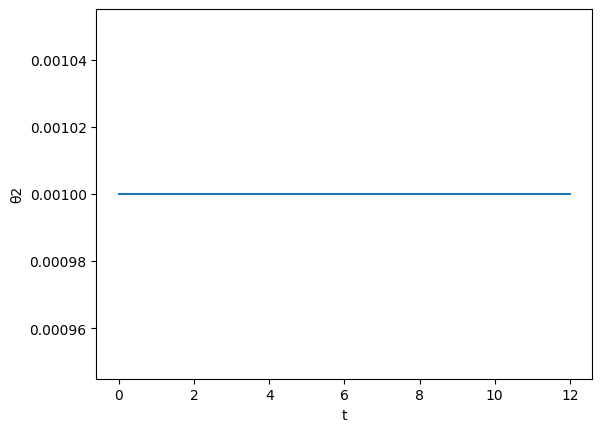

In [173]:
plt.plot(t,us.T[:,8*N+2],'-')
plt.xlabel('t')
plt.ylabel('θ2')
plt.show()

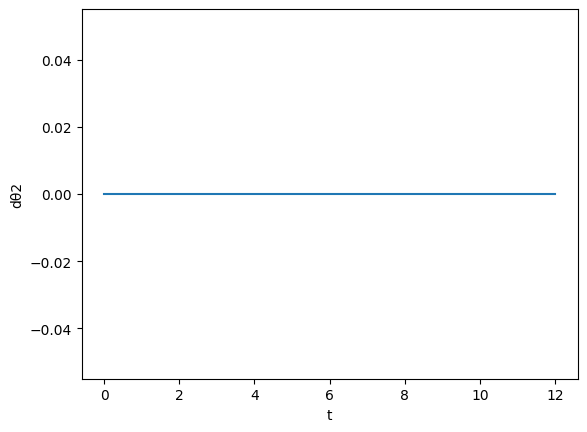

In [174]:
plt.plot(t,us.T[:,9*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dθ2')
plt.show()

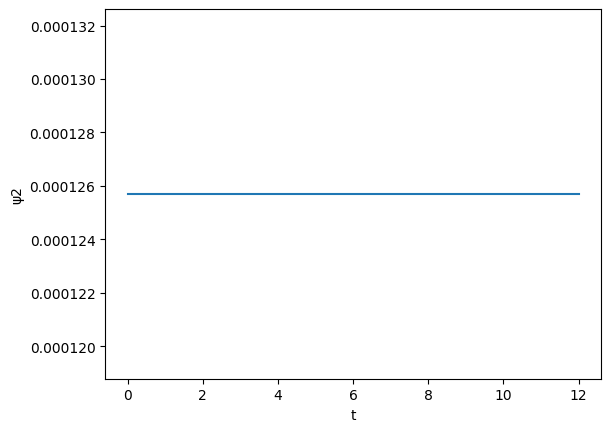

In [175]:
plt.plot(t,us.T[:,10*N+2],'-')
plt.xlabel('t')
plt.ylabel('ψ2')
plt.show()

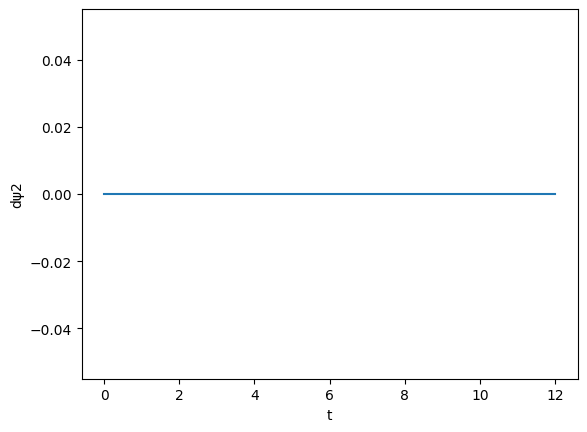

In [176]:
plt.plot(t,us.T[:,11*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dψ2')
plt.show()

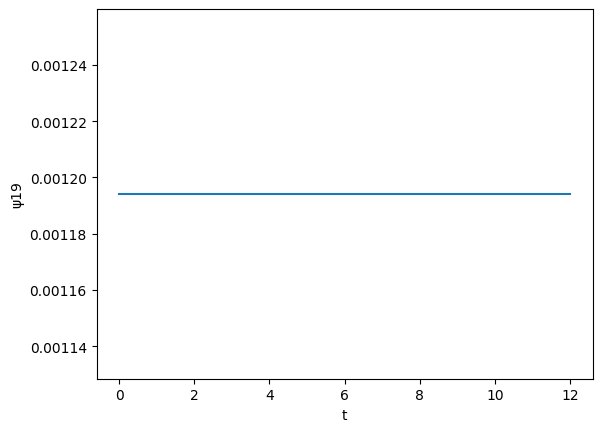

In [177]:
plt.plot(t,us.T[:,10*N + (N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('ψ{}'.format(N-1))
plt.show()

In [178]:
X010=us.T[:,0*N:1*N]

In [179]:
Y010=us.T[:,2*N:3*N]

In [180]:
Z010=us.T[:,4*N:5*N]

In [181]:
# simulation = np.stack([X010,Y010,Z010],axis=2) 

# FPS = 30                      
# frame_duration = 1000 / FPS

# frames = []
# for t in range(simulation.shape[0]):
#     x = simulation[t,:,0]
#     y = simulation[t,:,1]
#     z = simulation[t,:,2]

#     frames.append(go.Frame(
#         data=[
#             go.Scatter3d(
#                 x=x, y=y, z=z,
#                 mode="lines+markers",
#                 marker=dict(size=5, color=list(range(12)), colorscale="Viridis"),
#                 line=dict(width=4)
#             )
#         ],
#         name=f"t={t}"
#     ))

# # First frame
# x0, y0, z0 = simulation[0,:,0], simulation[0,:,1], simulation[0,:,2]

# fig = go.Figure(
#     data=[go.Scatter3d(x=x0, y=y0, z=z0, mode="lines+markers")],
#     frames=frames
# )

# # Animation controls
# fig.update_layout(
#     title="Pipeline Simulation ",
#     scene=dict(
#         xaxis_title="X",
#         yaxis_title="Y",
#         zaxis_title="Z",
#         xaxis=dict(range=[0, 300]),
#         yaxis=dict(range=[-50, 50]),
#         zaxis=dict(range=[0, 40]),
#         aspectmode="data",
       
#     ),
#     updatemenus=[{
#         "type": "buttons",
#         "buttons": [
#             {
#                 "label": "Play",
#                 "method": "animate",
#                 "args": [None, {"frame": {"duration": frame_duration, "redraw": True}}]
#             },
#             {
#                 "label": "Pause",
#                 "method": "animate",
#                 "args": [[None], {"frame": {"duration": 0}}]
#             }
#         ]
#     }]
# )

# fig.show()